# Phase 3B Research Discovery 1: Temporal Context & PPG/VPG/APG Controlled Experiments

## 1. Research Hypothesis

In Phase 3A, our calibration-free classical benchmarks established that:
1. Single-channel PPG features carry genuine blood pressure signal (validation MAE: 14.07 mmHg SBP / 6.98 mmHg DBP).
2. Derivative features (VPG and APG) are among the most informative descriptors.
3. However, static 10-second regression exhibits severe **regression-to-the-mean**, underestimating severe hypertension (SBP $\ge 160$ mmHg by ~30 mmHg) and overestimating hypotension (SBP $< 90$ mmHg by ~30 mmHg).

We formulate two specific, falsifiable research hypotheses:
- **Hypothesis 1 (Temporal Dynamics)**: *A single static 10-second PPG window loses information present in temporal evolution across consecutive windows. Sequential context (20–60s) will provide slow physiological trend and drift information, reducing regression-to-the-mean and extreme tail bias.*
- **Hypothesis 2 (Derivative Representation)**: *Explicit first (VPG) and second (APG) derivative representations capture arterial stiffness and wave reflection morphology not captured by pure pulse timing, providing orthogonal value independently of temporal context.*

**Scope Constraint**: Strictly CPU-only, zero-leakage, using the existing frozen `features_cache.h5`. No deep neural networks (CNN/LSTM/Transformers) are trained in this phase.



In [1]:
import sys
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Configure project paths
NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

OUTPUT_DIR = CODE_DIR / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
REPORTS_DIR = OUTPUT_DIR / "reports"
FIGURES_DIR = OUTPUT_DIR / "figures" / "phase3b_discovery"
FEATURES_DIR = OUTPUT_DIR / "features"

print("Environment initialized successfully.")
print(f"Metrics Directory: {METRICS_DIR}")
print(f"Figures Directory: {FIGURES_DIR}")



Environment initialized successfully.
Metrics Directory: /run/media/op/DATA/Omkar/VIT/4y/sem2/Capstone/code/outputs/metrics
Figures Directory: /run/media/op/DATA/Omkar/VIT/4y/sem2/Capstone/code/outputs/figures/phase3b_discovery


## 2. Frozen Phase 3A Baseline

We inspect the frozen configuration and benchmarks established in Phase 3A.



In [2]:
frozen_cfg_path = OUTPUT_DIR / "models" / "frozen_configuration.json"
with open(frozen_cfg_path, "r") as f:
    frozen_cfg = json.load(f)

print("Frozen Phase 3A Champion Configuration:")
print(f"  Model: {frozen_cfg['model']}")
print(f"  Branch: {frozen_cfg['representation_branch']}")
print(f"  Feature Count: {frozen_cfg['feature_count']}")
print(f"  Hyperparameters: {frozen_cfg['hyperparameters']}")
print(f"  Validation Combined MAE: {frozen_cfg['val_combined_mae']:.4f} mmHg")



Frozen Phase 3A Champion Configuration:
  Model: hist_gradient_boosting
  Branch: Branch_C_Combined
  Feature Count: 40
  Hyperparameters: {'max_iter': 150, 'max_depth': 8, 'random_state': 42}
  Validation Combined MAE: 10.4993 mmHg


## 3. Feature Cache Verification

We programmatically verify the contents, keys, data types, and dimensions of `features_cache.h5`.



In [3]:
h5_path = FEATURES_DIR / "features_cache.h5"
assert h5_path.exists(), f"Feature cache missing at {h5_path}"

with h5py.File(h5_path, "r") as f:
    print(f"HDF5 Datasets in {h5_path.name}:")
    for k in f.keys():
        print(f"  {k:22s} shape={str(f[k].shape):16s} dtype={f[k].dtype}")
    
    feature_names = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in f["feature_names"][:]]

print(f"\nTotal cached features ({len(feature_names)}):")
print(feature_names)



HDF5 Datasets in features_cache.h5:
  dbp                    shape=(261339,)        dtype=float64
  feature_names          shape=(40,)            dtype=object
  features               shape=(261339, 40)     dtype=float64
  map                    shape=(261339,)        dtype=float64
  ppg_clipped_fraction   shape=(261339,)        dtype=float64
  ppg_quality_status     shape=(261339,)        dtype=object
  record_id              shape=(261339,)        dtype=object
  sbp                    shape=(261339,)        dtype=float64
  split                  shape=(261339,)        dtype=object
  window_id              shape=(261339,)        dtype=object
  window_quality_status  shape=(261339,)        dtype=object

Total cached features (40):
['mean_a', 'std_a', 'var_a', 'rms_a', 'ptp_a', 'min_a', 'max_a', 'median_a', 'iqr_a', 'p10_a', 'p90_a', 'pulse_amp_median_a', 'pulse_amp_iqr_a', 'pulse_amp_cv_a', 'skew_b', 'kurt_b', 'pulse_count', 'hr_bpm', 'ibi_mean', 'ibi_median', 'ibi_std', 'ibi_cv', 'pul

## 4. Temporal Ordering Validation

Temporal sequence construction requires that all records have strictly monotonically increasing window indices and that no sequences cross record boundaries.



In [4]:
from modeling.temporal_features import assert_temporal_sequence_integrity, TemporalSequenceBuilder

with h5py.File(h5_path, "r") as f:
    sample_win_ids = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in f["window_id"][:10000]]
    sample_rec_ids = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in f["record_id"][:10000]]
    sample_splits = [x.decode("utf-8") if isinstance(x, bytes) else str(x) for x in f["split"][:10000]]

df_check = pd.DataFrame({
    "record_id": sample_rec_ids,
    "window_id": sample_win_ids,
    "win_idx": [int(w.split("_win_")[-1]) for w in sample_win_ids],
    "split": sample_splits,
})

# Verify strict monotonic ordering within each record
monotone_checks = []
for r_id, grp in df_check.groupby("record_id"):
    idxs = grp["win_idx"].values
    if len(idxs) > 1:
        monotone_checks.append(np.all(np.diff(idxs) > 0))

print(f"Audited {len(monotone_checks)} sample records: all strictly monotonic = {all(monotone_checks)}")



Audited 280 sample records: all strictly monotonic = True


## 5. Sequence Construction & Retention

We review the missing history audit across the 4 evaluated context lengths:
- **Context-0 (10s)**: Current window only ($W_t$)
- **Context-1 (20s)**: $W_{t-1} \to W_t$
- **Context-2 (30s)**: $W_{t-2} \to W_{t-1} \to W_t$
- **Context-5 (60s)**: $W_{t-5} \to \dots \to W_t$



,context_label,context_sec,feature_count,train_samples,val_samples
0,Context-0 (10s),10.0,40,183517,39461
1,Context-1 (20s),20.0,222,175829,37810
2,Context-2 (30s),30.0,222,168667,36271
3,Context-5 (60s),60.0,222,149500,32163


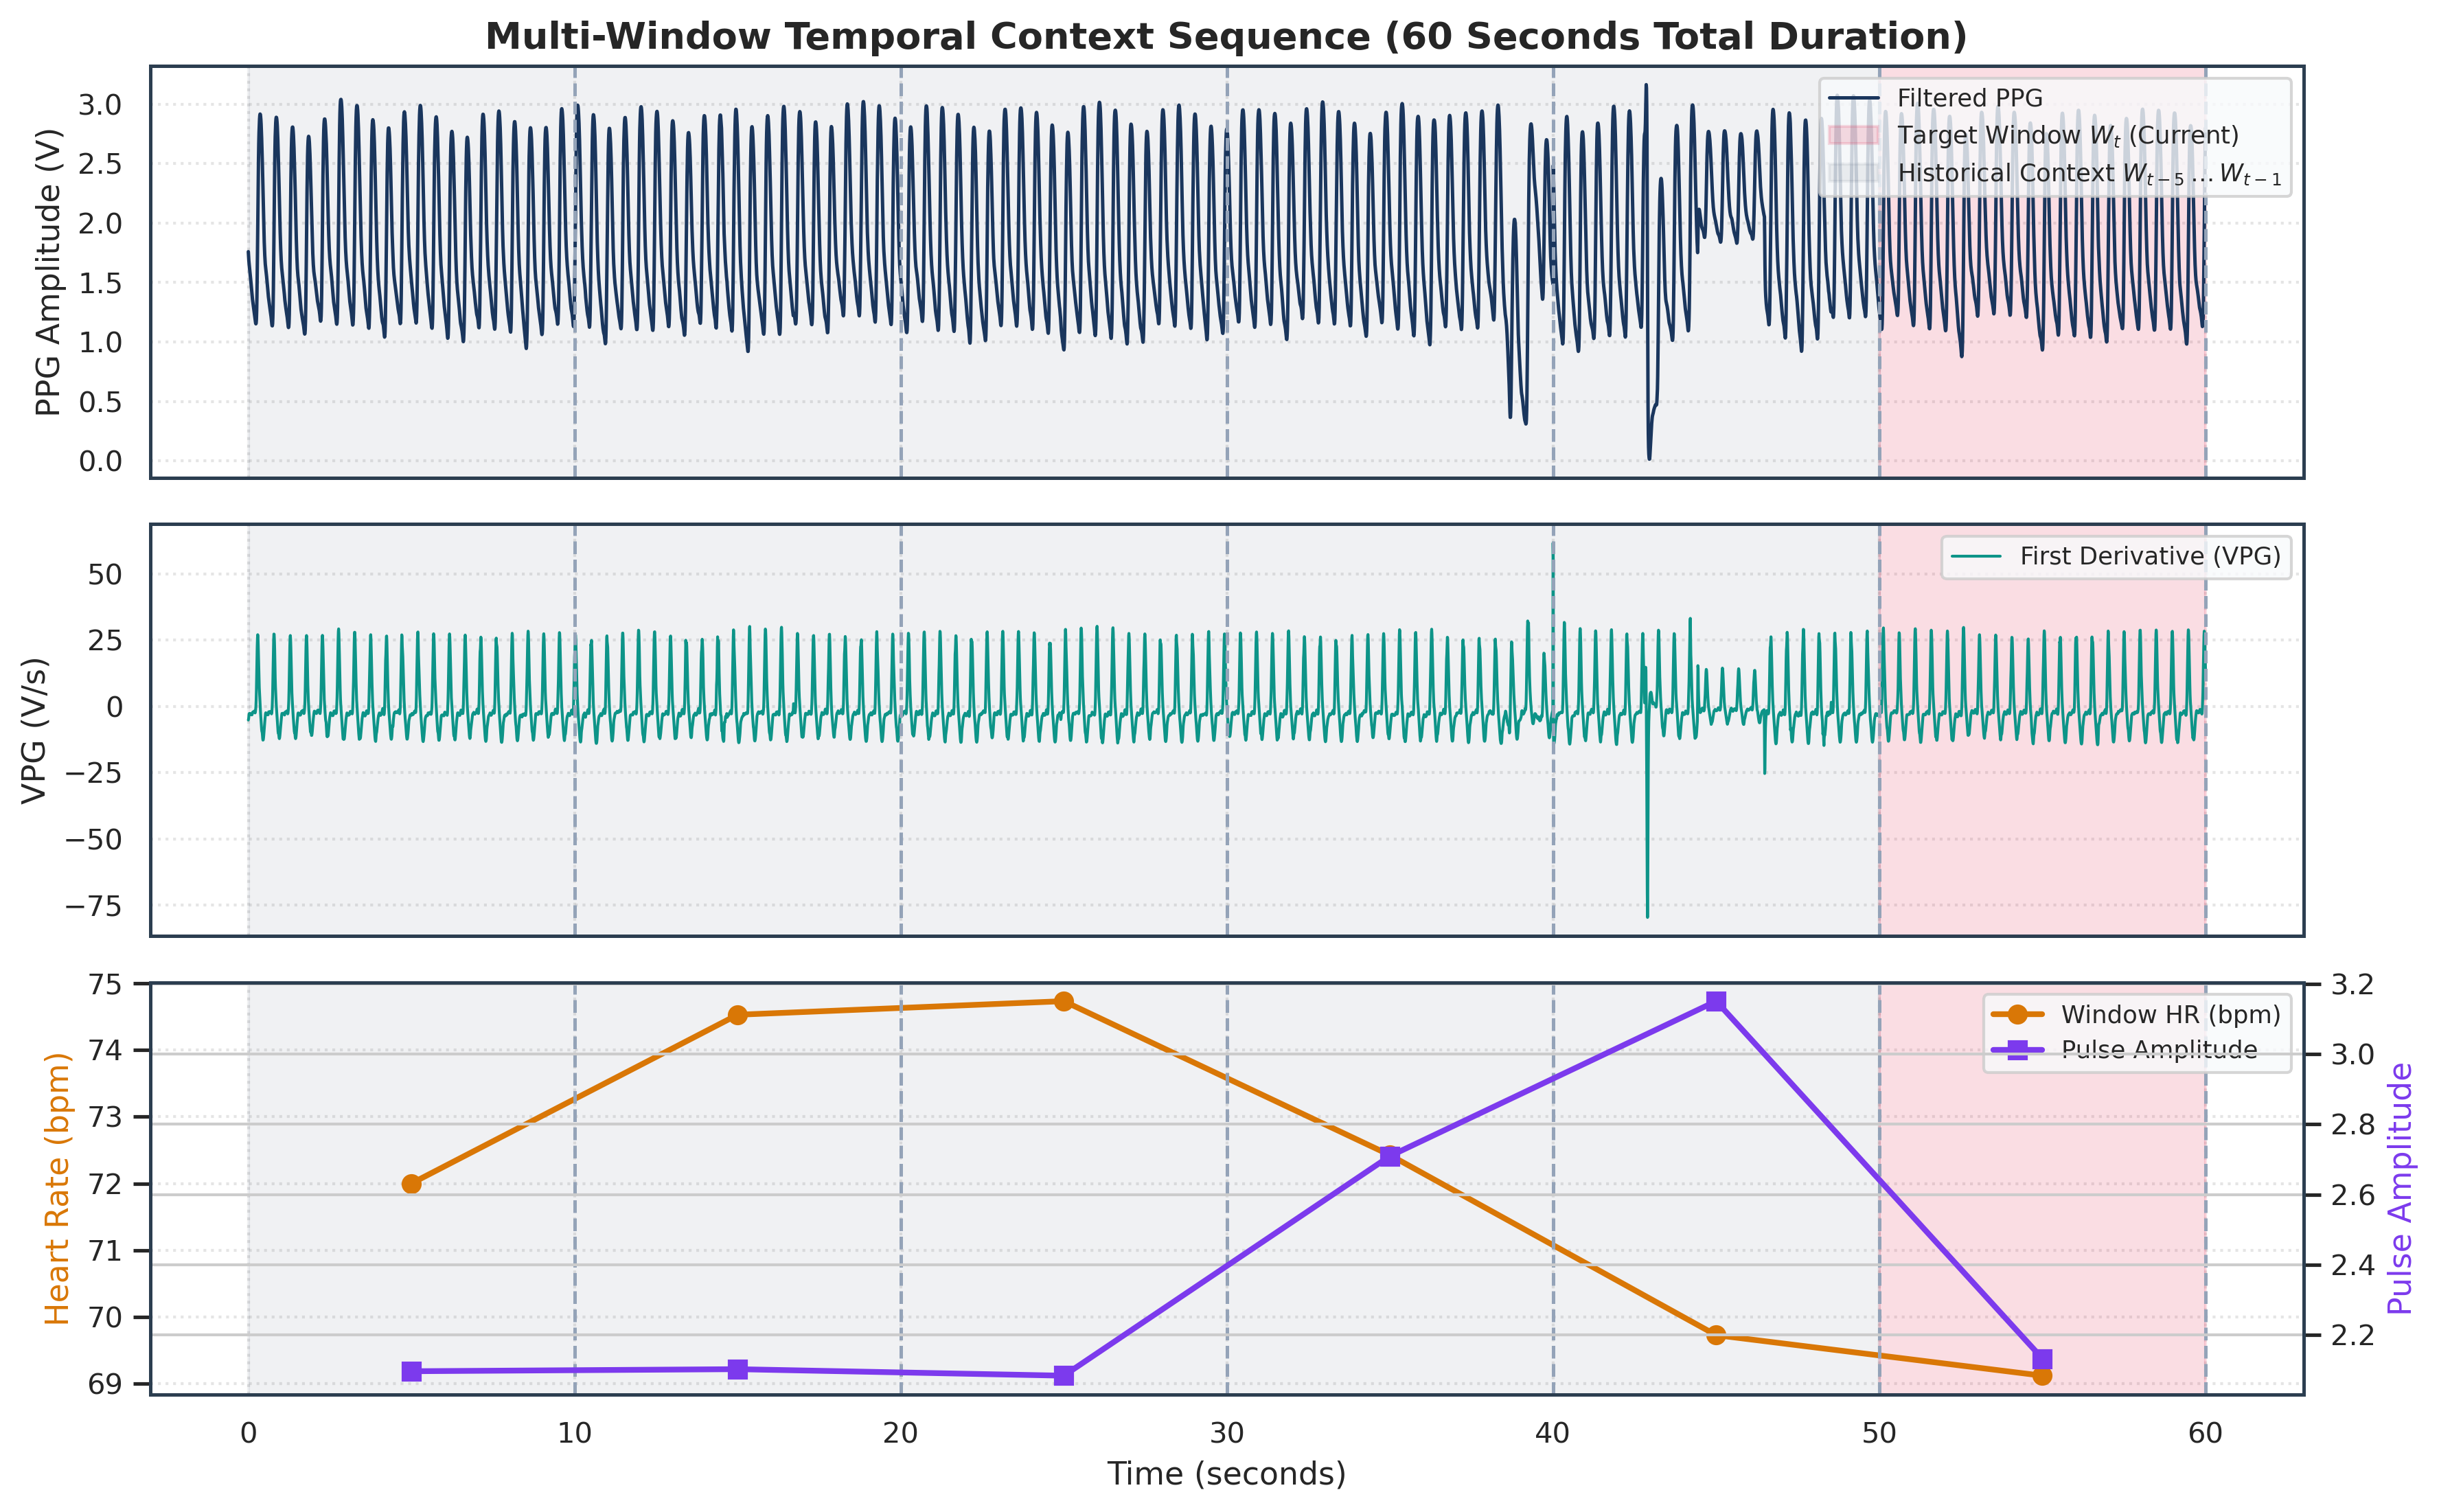

In [5]:
df_exp_b = pd.read_csv(METRICS_DIR / "phase3b_context_length_results.csv")
display(df_exp_b[["context_label", "context_sec", "feature_count", "train_samples", "val_samples"]])

# Multi-window temporal context visualization
display(Image(filename=str(FIGURES_DIR / "10_temporal_context_example.png")))



## 6. Context-0 Baseline (Experiment A)

Context-0 represents the exact Phase 3A static baseline evaluated on the same feature set.



In [6]:
c0_row = df_exp_b[df_exp_b["context_k"] == 0].iloc[0]
print("Context-0 Baseline Performance (Validation Set):")
print(f"  SBP MAE: {c0_row['sbp_mae_all']:.2f} mmHg (RMSE: {c0_row['sbp_rmse_all']:.2f}, R2: {c0_row['sbp_r2']:.3f})")
print(f"  DBP MAE: {c0_row['dbp_mae_all']:.2f} mmHg (RMSE: {c0_row['dbp_rmse_all']:.2f}, R2: {c0_row['dbp_r2']:.3f})")
print(f"  Combined MAE: {c0_row['comb_mae_all']:.2f} mmHg")



Context-0 Baseline Performance (Validation Set):
  SBP MAE: 14.02 mmHg (RMSE: 18.24, R2: 0.293)
  DBP MAE: 6.99 mmHg (RMSE: 9.52, R2: 0.241)
  Combined MAE: 10.50 mmHg


## 7. Context-1 Evaluation (20 Seconds History)

Context-1 introduces the immediately preceding 10-second window ($W_{t-1} \to W_t$).



In [7]:
c1_row = df_exp_b[df_exp_b["context_k"] == 1].iloc[0]
print("Context-1 Performance (Validation Set):")
print(f"  SBP MAE: {c1_row['sbp_mae_all']:.2f} mmHg (Δ vs C0: {c1_row['sbp_mae_all'] - c0_row['sbp_mae_all']:+.2f} mmHg)")
print(f"  DBP MAE: {c1_row['dbp_mae_all']:.2f} mmHg (Δ vs C0: {c1_row['dbp_mae_all'] - c0_row['dbp_mae_all']:+.2f} mmHg)")
print(f"  Combined MAE: {c1_row['comb_mae_all']:.2f} mmHg")



Context-1 Performance (Validation Set):
  SBP MAE: 13.95 mmHg (Δ vs C0: -0.06 mmHg)
  DBP MAE: 6.89 mmHg (Δ vs C0: -0.10 mmHg)
  Combined MAE: 10.42 mmHg


## 8. Context-2 Evaluation (30 Seconds History)

Context-2 introduces two preceding windows ($W_{t-2} \to W_{t-1} \to W_t$).



In [8]:
c2_row = df_exp_b[df_exp_b["context_k"] == 2].iloc[0]
print("Context-2 Performance (Validation Set):")
print(f"  SBP MAE: {c2_row['sbp_mae_all']:.2f} mmHg (Δ vs C0: {c2_row['sbp_mae_all'] - c0_row['sbp_mae_all']:+.2f} mmHg)")
print(f"  DBP MAE: {c2_row['dbp_mae_all']:.2f} mmHg (Δ vs C0: {c2_row['dbp_mae_all'] - c0_row['dbp_mae_all']:+.2f} mmHg)")
print(f"  Combined MAE: {c2_row['comb_mae_all']:.2f} mmHg")



Context-2 Performance (Validation Set):
  SBP MAE: 13.69 mmHg (Δ vs C0: -0.33 mmHg)
  DBP MAE: 6.78 mmHg (Δ vs C0: -0.21 mmHg)
  Combined MAE: 10.23 mmHg


## 9. Context-5 Evaluation (60 Seconds History)

Context-5 introduces five preceding windows (50s of historical context + 10s current window).



In [9]:
c5_row = df_exp_b[df_exp_b["context_k"] == 5].iloc[0]
print("Context-5 Performance (Validation Set):")
print(f"  SBP MAE: {c5_row['sbp_mae_all']:.2f} mmHg (Δ vs C0: {c5_row['sbp_mae_all'] - c0_row['sbp_mae_all']:+.2f} mmHg)")
print(f"  DBP MAE: {c5_row['dbp_mae_all']:.2f} mmHg (Δ vs C0: {c5_row['dbp_mae_all'] - c0_row['dbp_mae_all']:+.2f} mmHg)")
print(f"  Combined MAE: {c5_row['comb_mae_all']:.2f} mmHg")



Context-5 Performance (Validation Set):
  SBP MAE: 13.28 mmHg (Δ vs C0: -0.74 mmHg)
  DBP MAE: 6.56 mmHg (Δ vs C0: -0.43 mmHg)
  Combined MAE: 9.92 mmHg


## 10. Explicit PPG vs VPG vs APG Comparison (Experiment C)

We evaluate whether derivative representations (VPG and APG) provide measurable improvements at a fixed static window (Context-0).



In [10]:
df_exp_c = pd.read_csv(METRICS_DIR / "phase3b_derivative_ablation_results.csv")
display(df_exp_c)



,label,feature_count,sbp_mae,sbp_rmse,sbp_r2,dbp_mae,dbp_rmse,dbp_r2,comb_mae
0,C1 (PPG Only),31,14.407136,18.700390,0.256916,7.291695,9.853881,0.186653,10.849416
1,C2 (PPG + VPG),36,14.272071,18.559358,0.268082,7.097567,9.640045,0.221570,10.684819
2,C3 (PPG + VPG + APG),40,14.016249,18.243013,0.292820,6.991558,9.516769,0.241352,10.503904


## 11. Temporal + Derivative Interaction (Experiment D)

We examine the interaction of temporal context and derivative representations:
- **D1**: Current PPG only
- **D2**: Current PPG + VPG + APG
- **D3**: Temporal PPG only
- **D4**: Temporal PPG + VPG + APG (Combined full model)



,label,feature_count,sbp_mae,sbp_rmse,sbp_r2,dbp_mae,dbp_rmse,dbp_r2,comb_mae
0,D1: Static PPG Only (10s),31,14.407136,18.700390,0.256916,7.291695,9.853881,0.186653,10.849416
1,D2: Static PPG+VPG+APG (10s),40,14.016249,18.243013,0.292820,6.991558,9.516769,0.241352,10.503904
2,D3: Temporal PPG Only (60s),150,13.893044,18.016145,0.298984,6.935814,9.364158,0.236932,10.414429
3,D4: Temporal PPG+VPG+APG (60s),222,13.279596,17.305614,0.353187,6.561767,8.910356,0.309099,9.920681


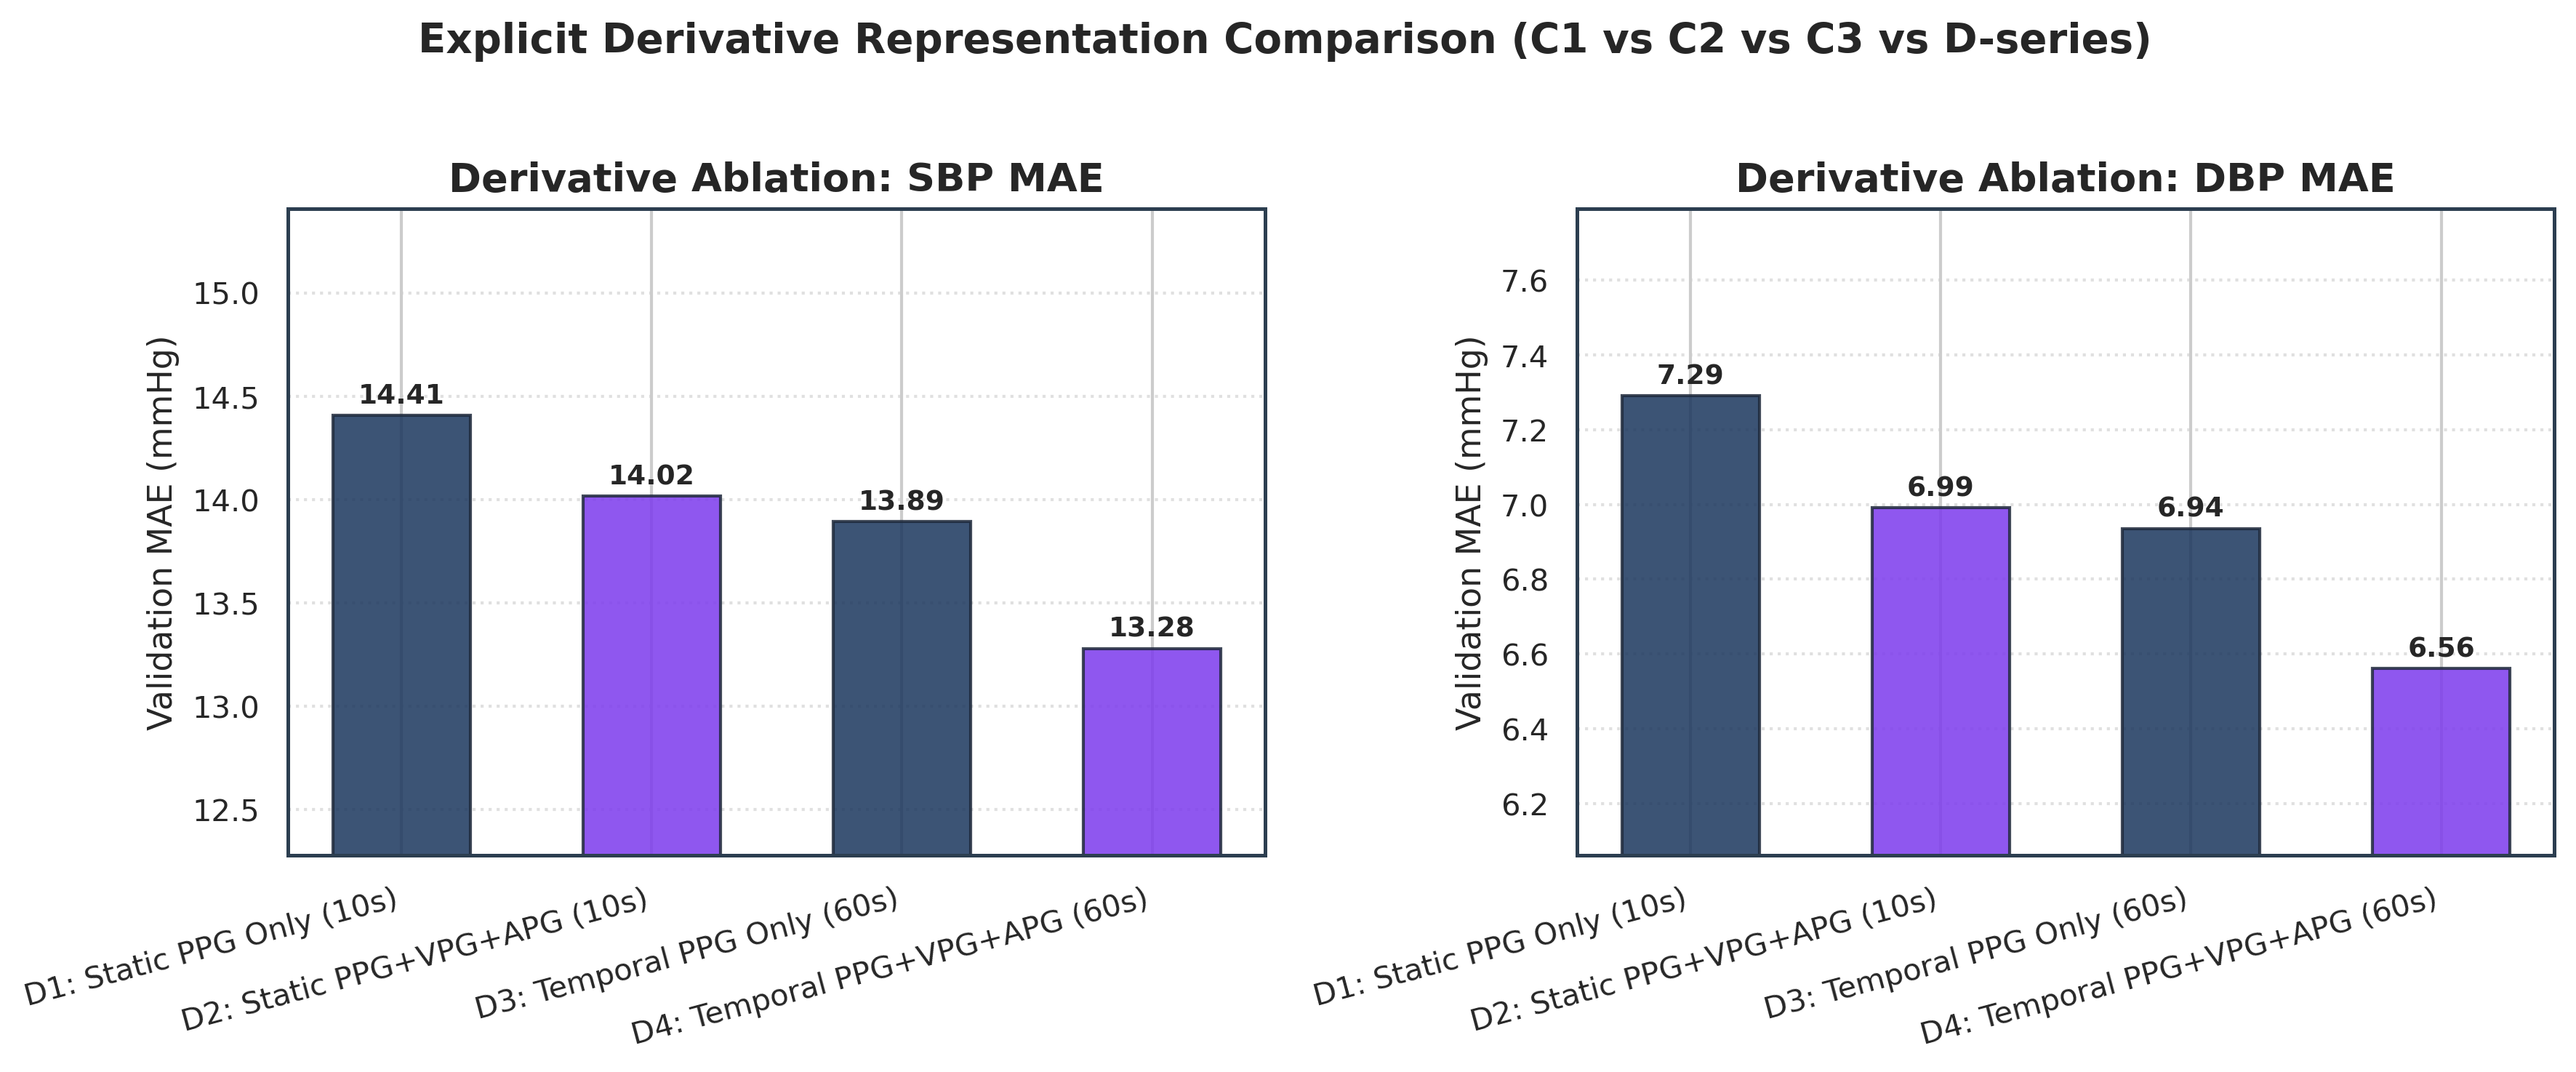

In [11]:
df_exp_d = pd.read_csv(METRICS_DIR / "phase3b_temporal_derivative_interaction.csv")
display(df_exp_d)

# Plot derivative ablation and interaction
display(Image(filename=str(FIGURES_DIR / "08_ppg_vpg_apg_ablation.png")))



## 12. Validation Context Length Comparison Plots

We plot SBP and DBP MAE and $R^2$ across context durations.



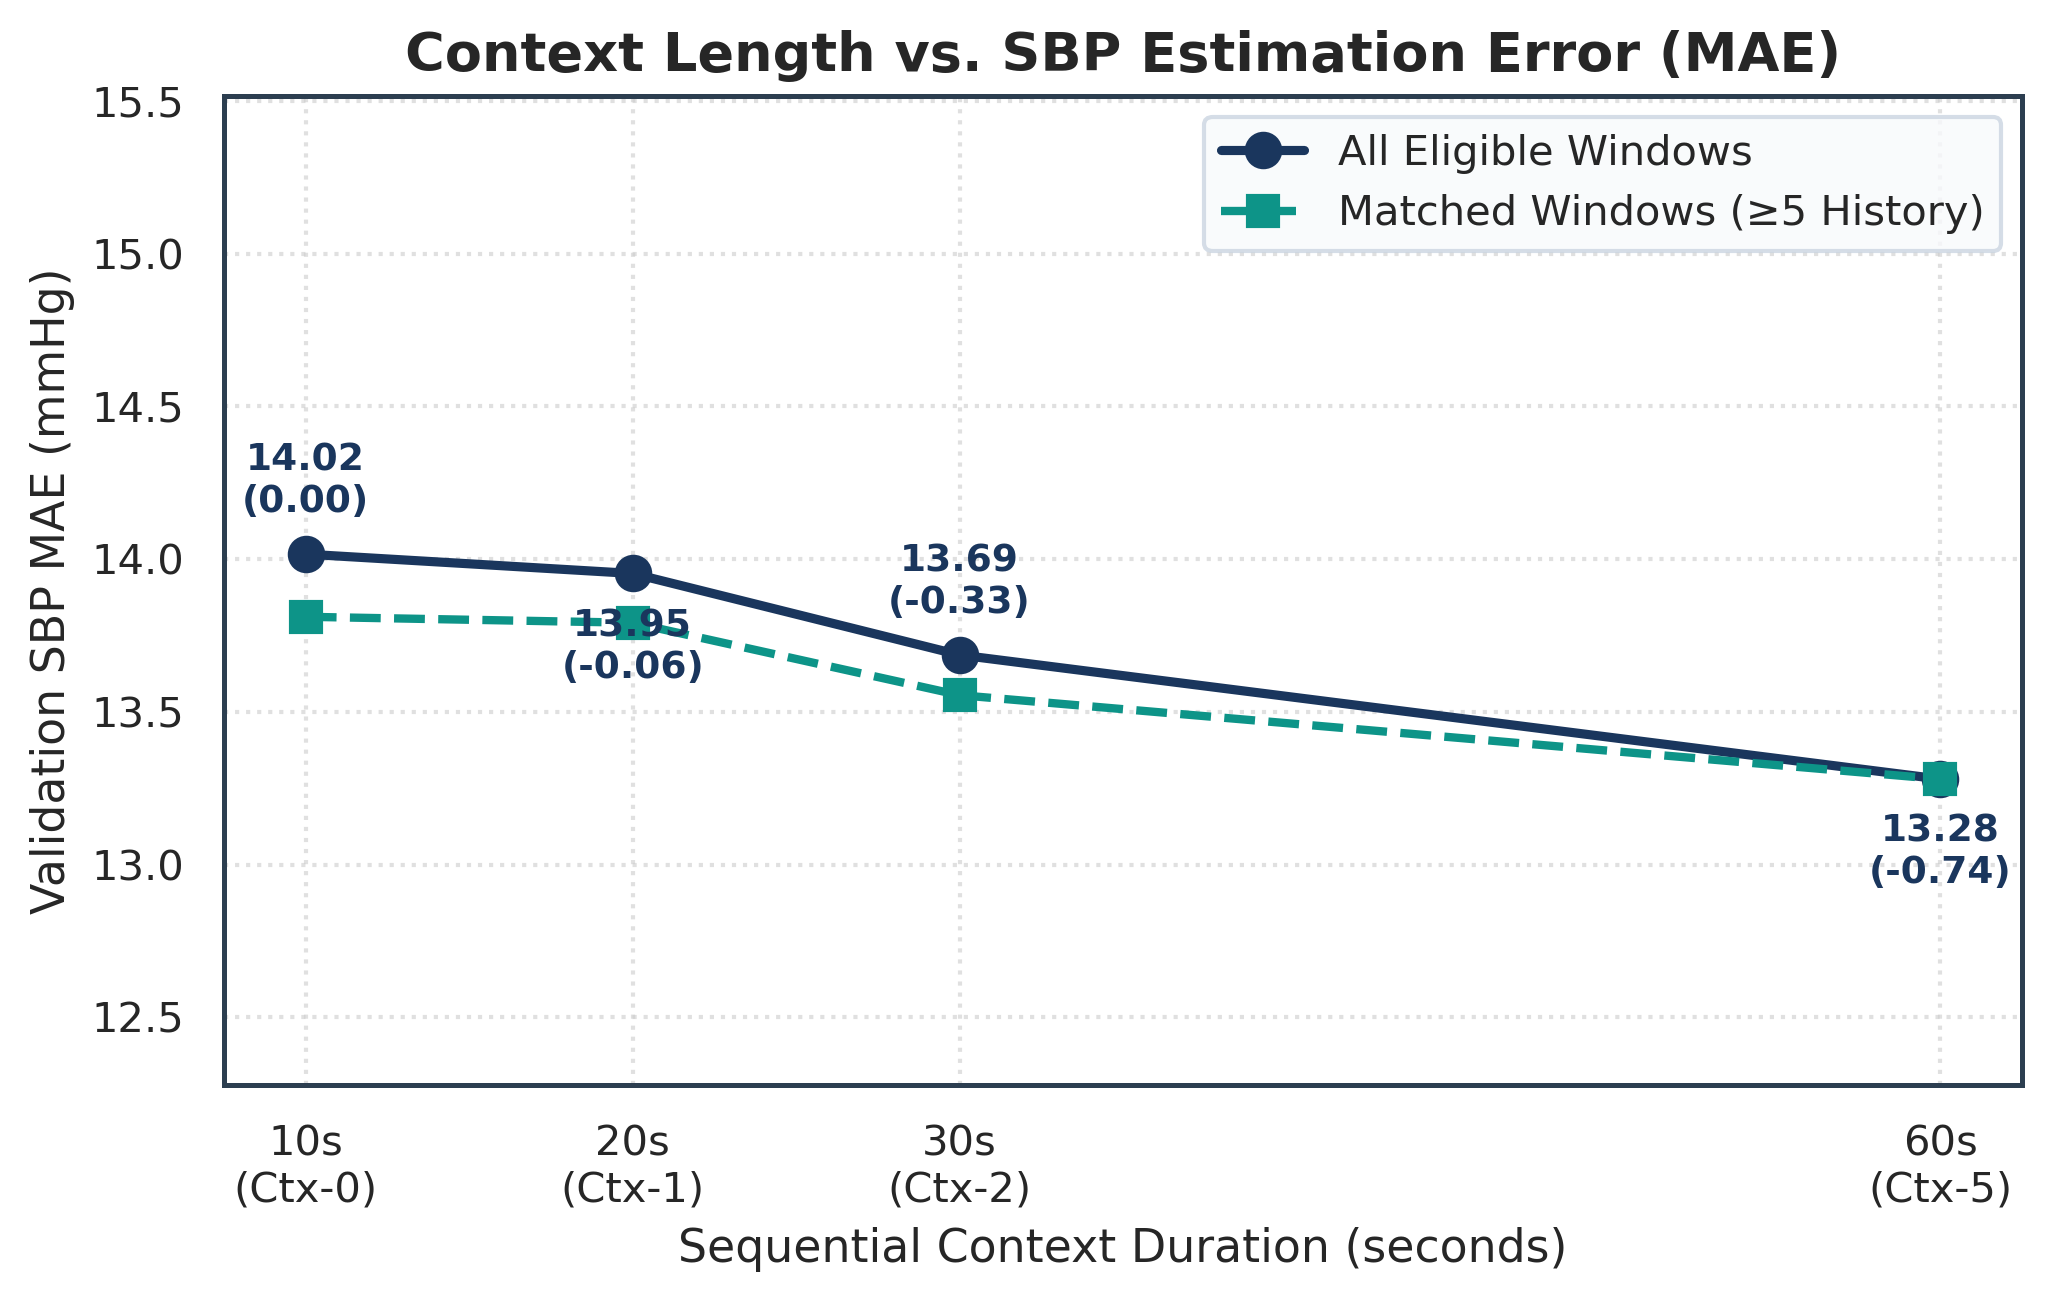

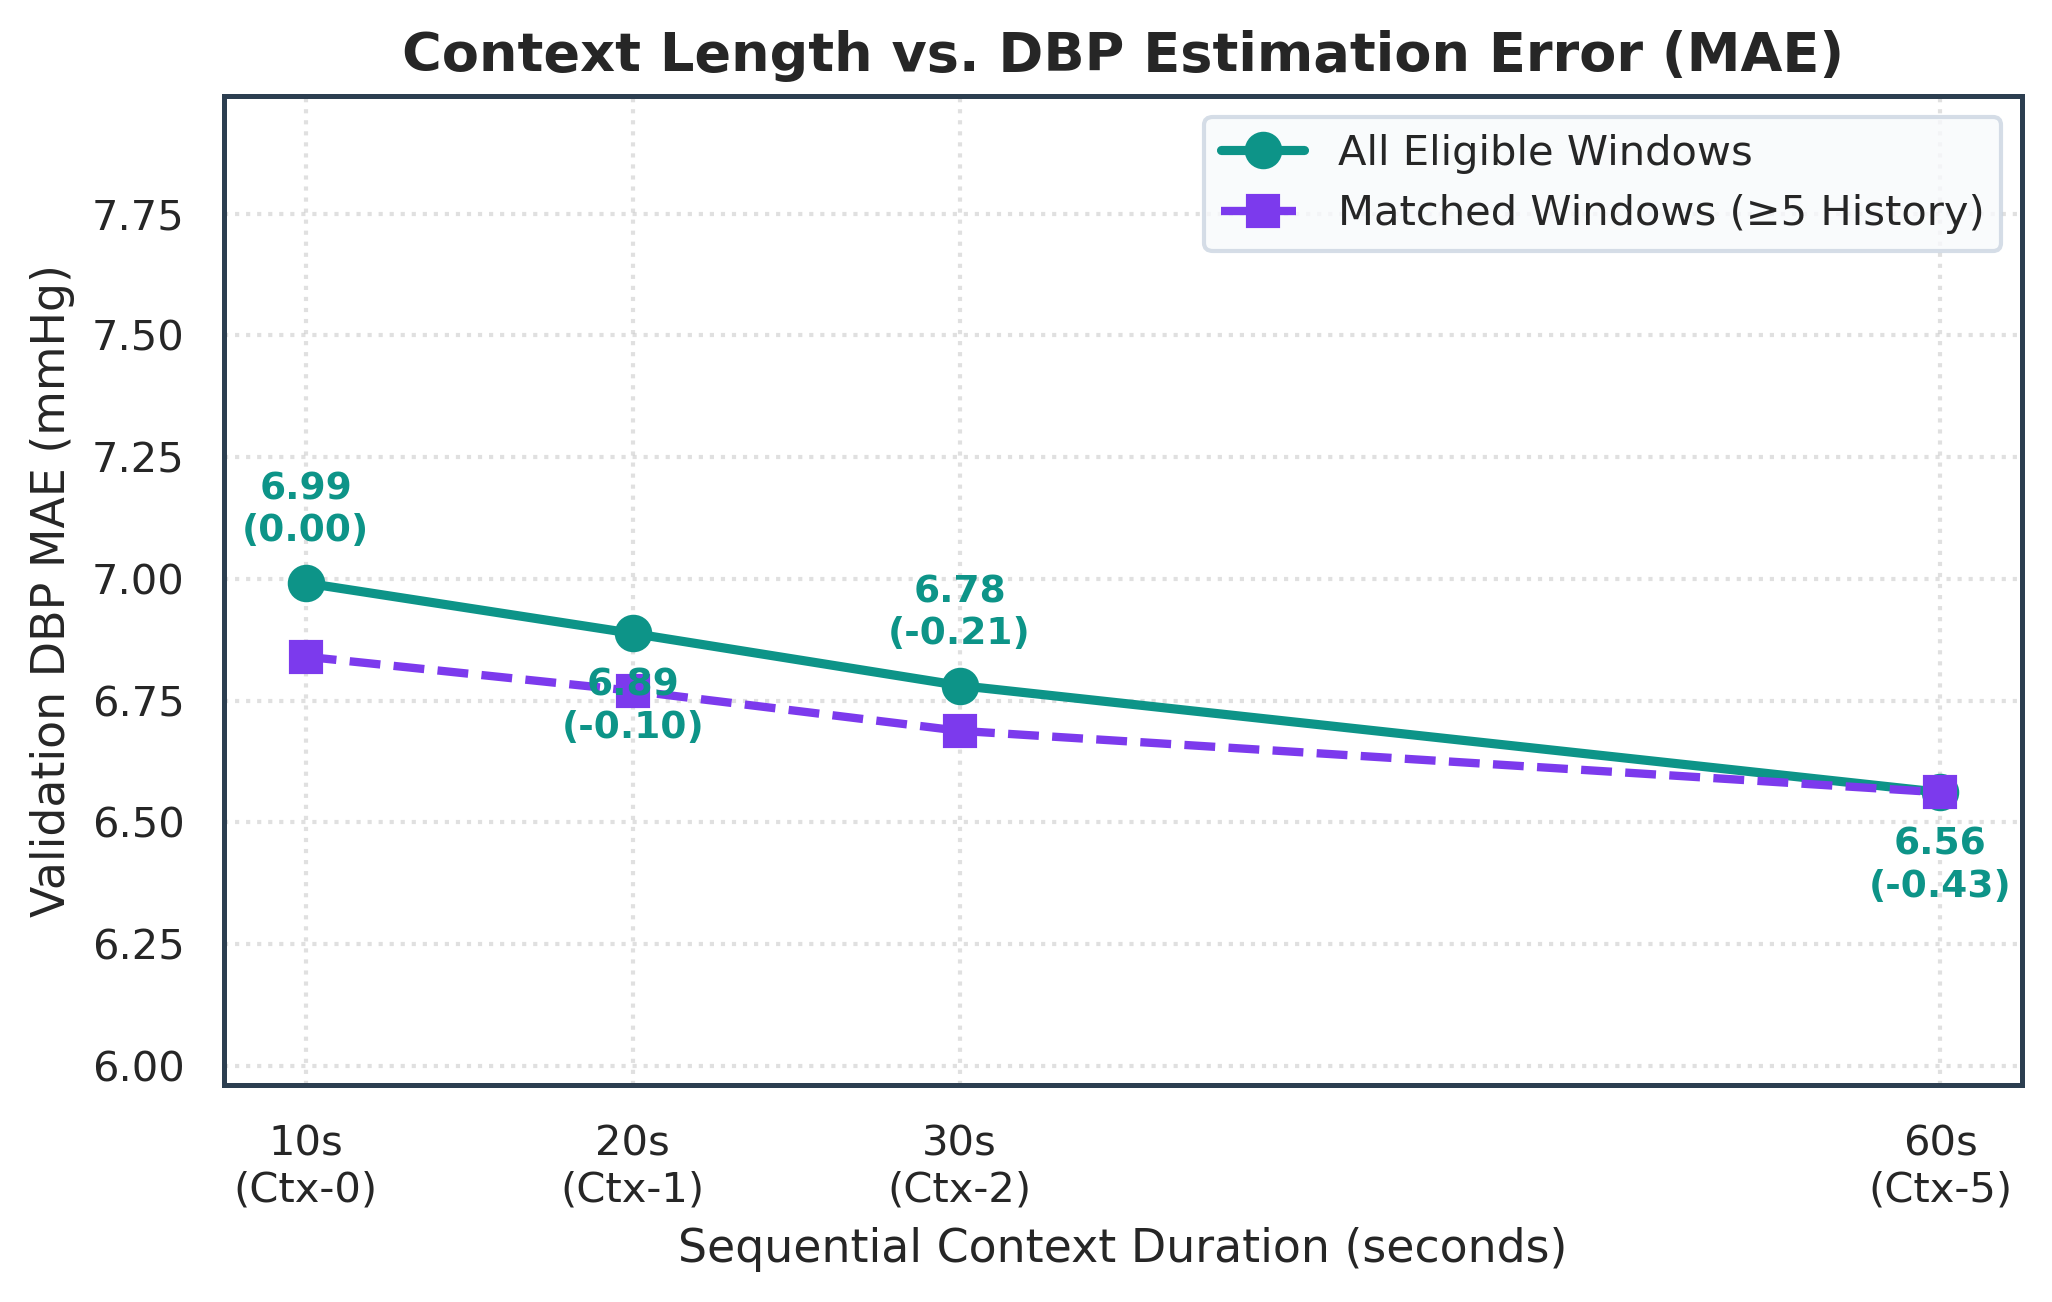

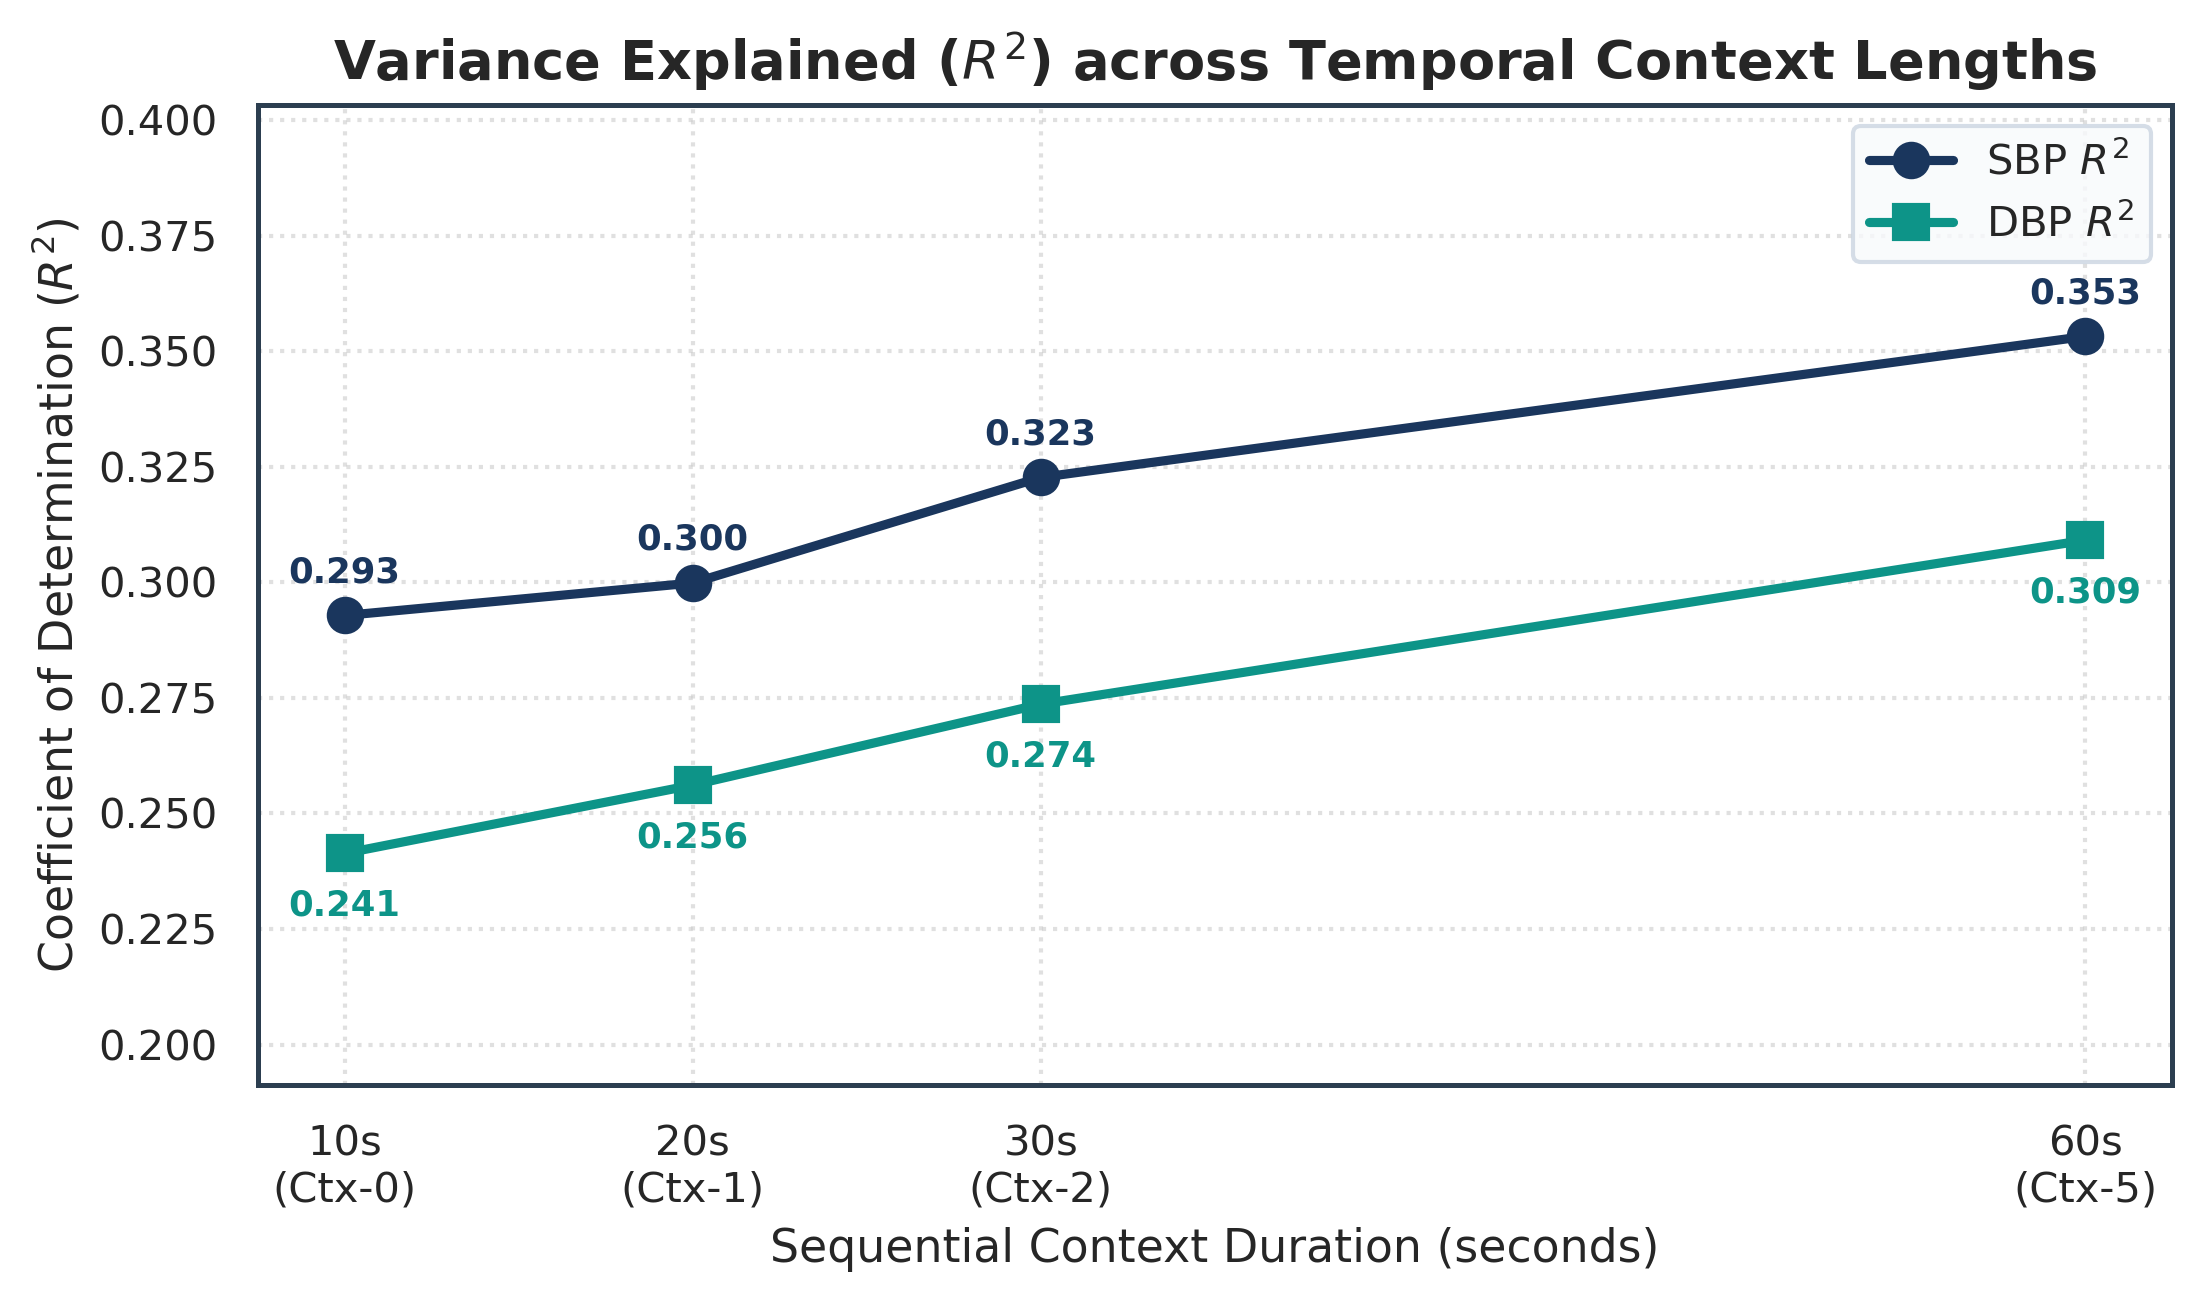

In [12]:
display(Image(filename=str(FIGURES_DIR / "01_context_length_vs_sbp_mae.png")))
display(Image(filename=str(FIGURES_DIR / "02_context_length_vs_dbp_mae.png")))
display(Image(filename=str(FIGURES_DIR / "05_context_length_vs_r2.png")))



## 13. BP-Range & Extreme BP Bias Analysis

Does temporal context reduce the severe tail bias observed in Phase 3A?



,context_label,range,sample_count,mae,bias,error_sd
0,Context-0 (10s),<90,800,33.894463,33.820141,15.025787
1,Context-0 (10s),>=160,3595,31.480491,-31.362978,14.391393
2,Context-1 (20s),<90,745,33.603672,33.360178,15.196483
3,Context-1 (20s),>=160,3451,31.176292,-31.000265,14.471811
4,Context-2 (30s),<90,693,32.611876,32.534916,15.010166
5,Context-2 (30s),>=160,3311,30.007586,-29.836559,14.536516
6,Context-5 (60s),<90,570,30.940437,30.915614,15.116443
7,Context-5 (60s),>=160,2935,28.898343,-28.591239,14.731968


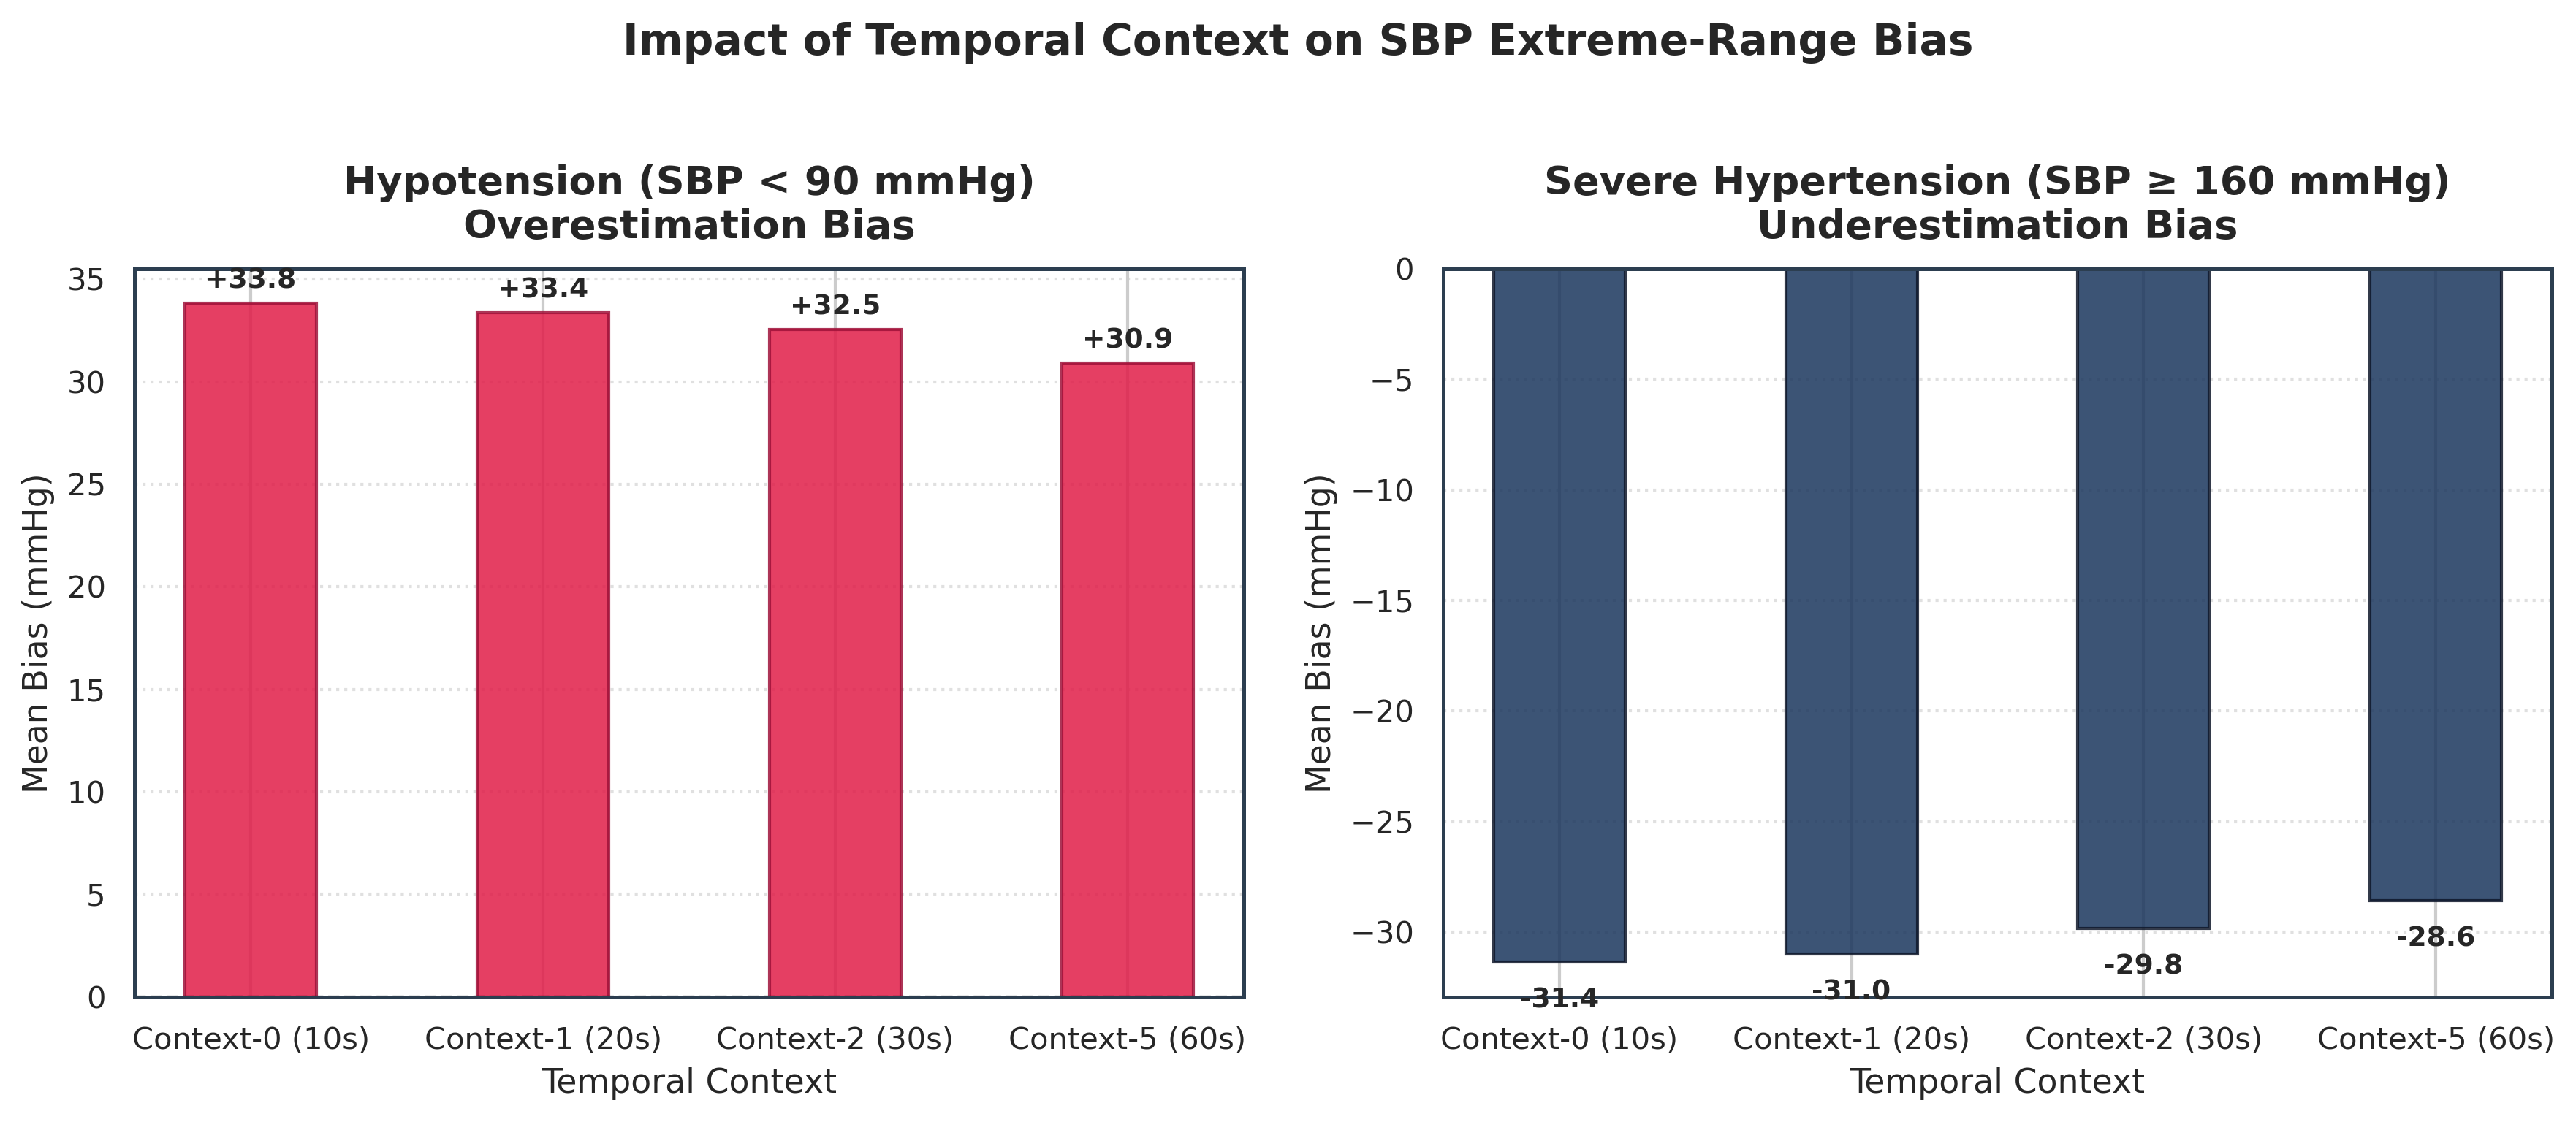

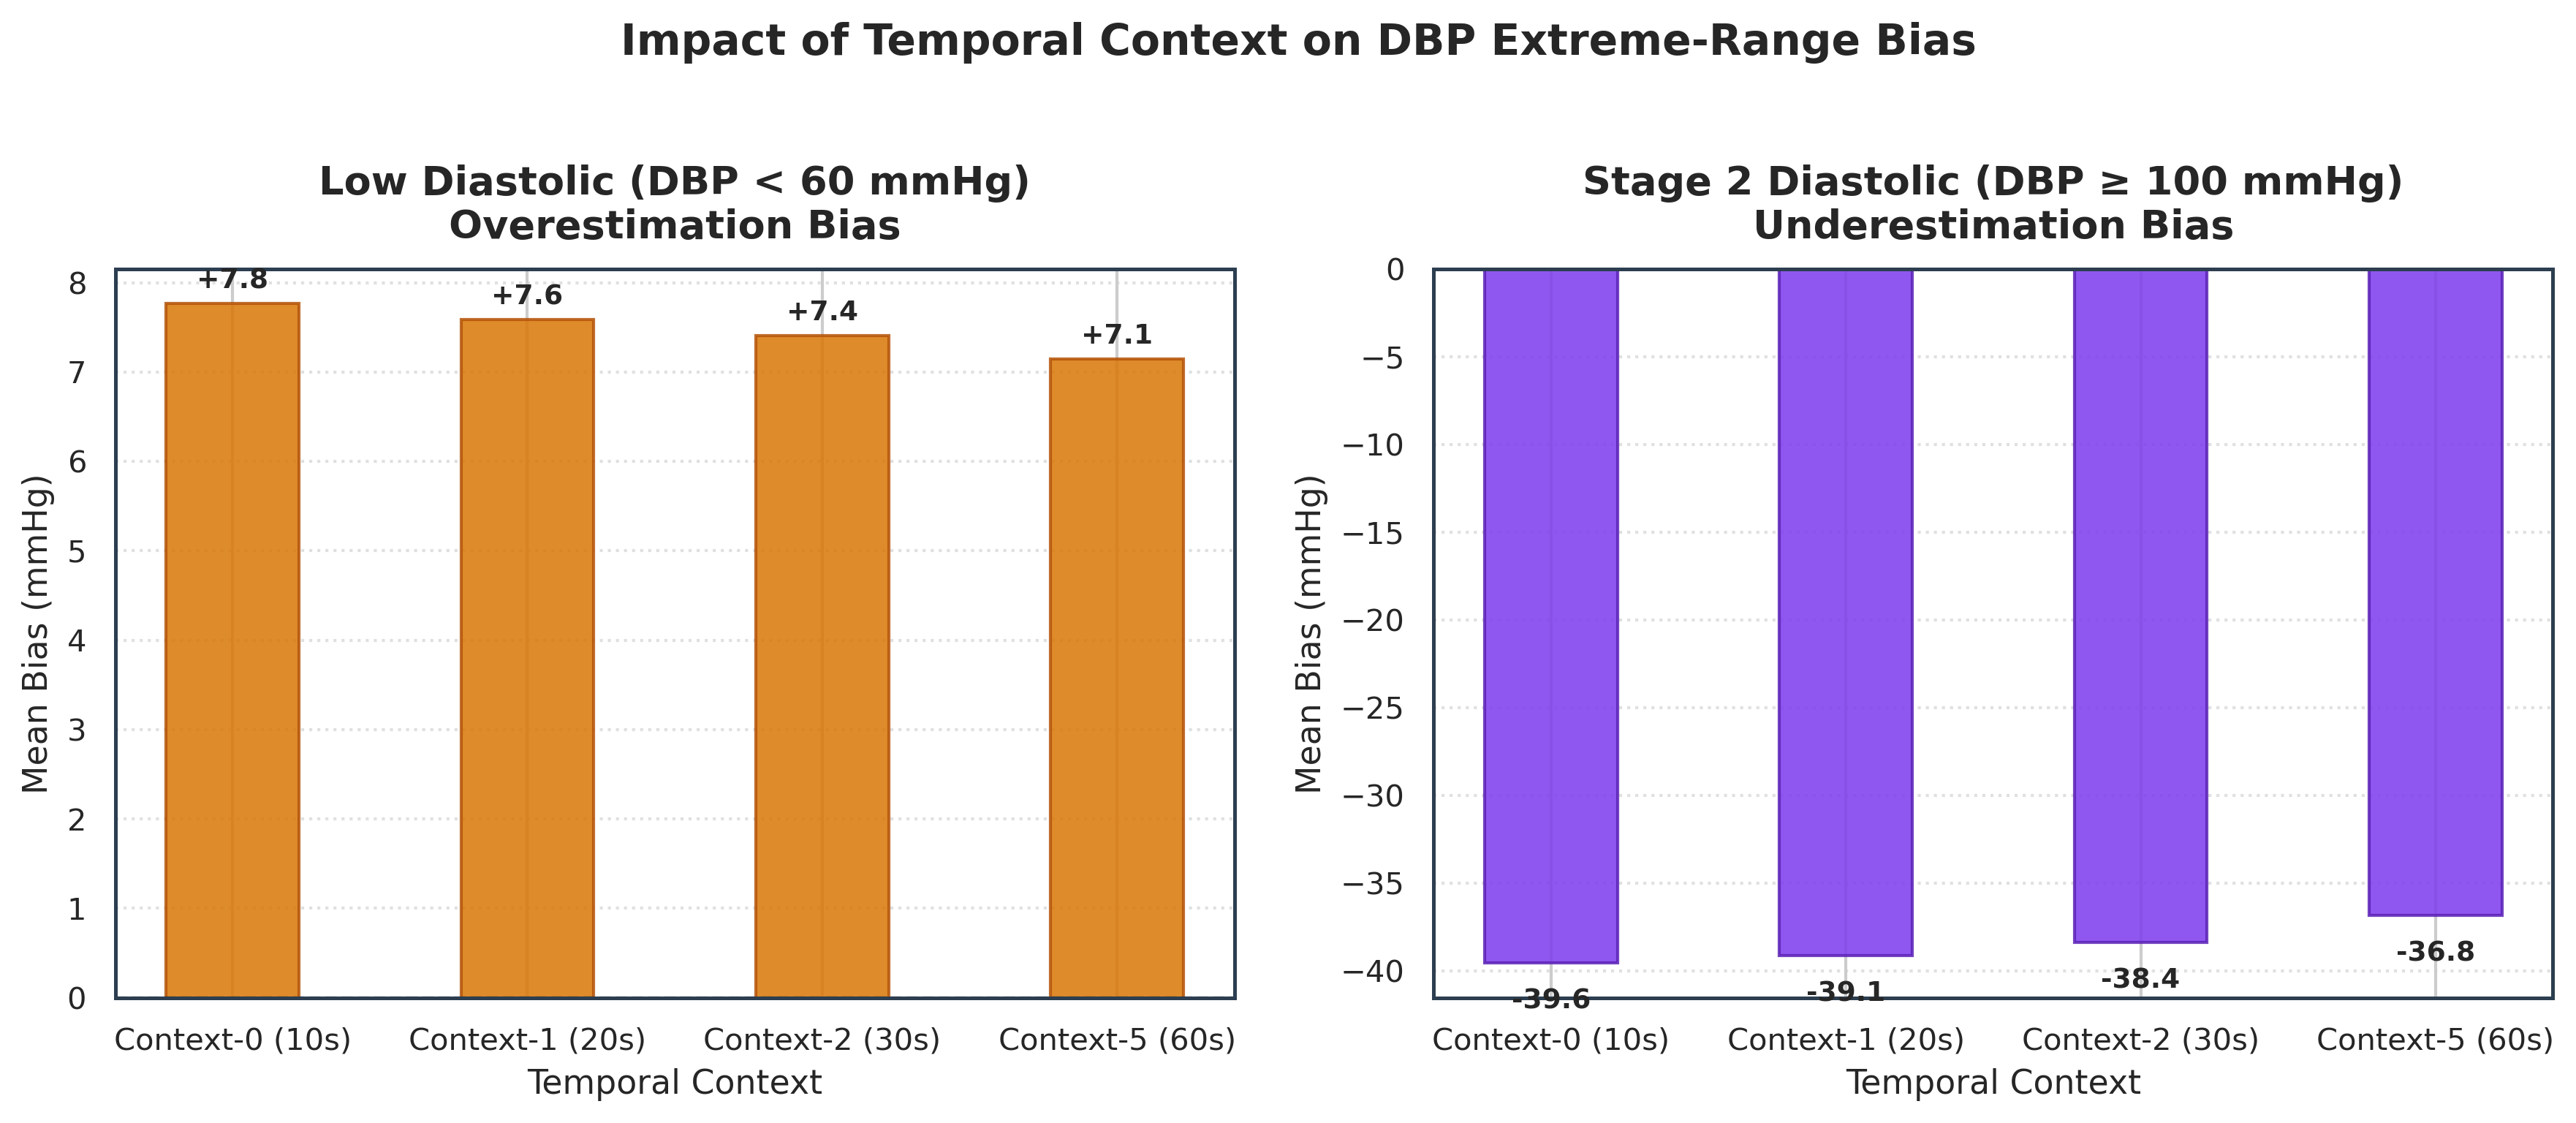

In [13]:
df_ext_sbp = pd.read_csv(METRICS_DIR / "phase3b_extreme_sbp_bias.csv")
display(df_ext_sbp[["context_label", "range", "sample_count", "mae", "bias", "error_sd"]])

display(Image(filename=str(FIGURES_DIR / "03_context_length_vs_sbp_extreme_bias.png")))
display(Image(filename=str(FIGURES_DIR / "04_context_length_vs_dbp_extreme_bias.png")))



## 14. Regression-to-the-Mean Analysis

We compare error-vs-reference slopes across context lengths.



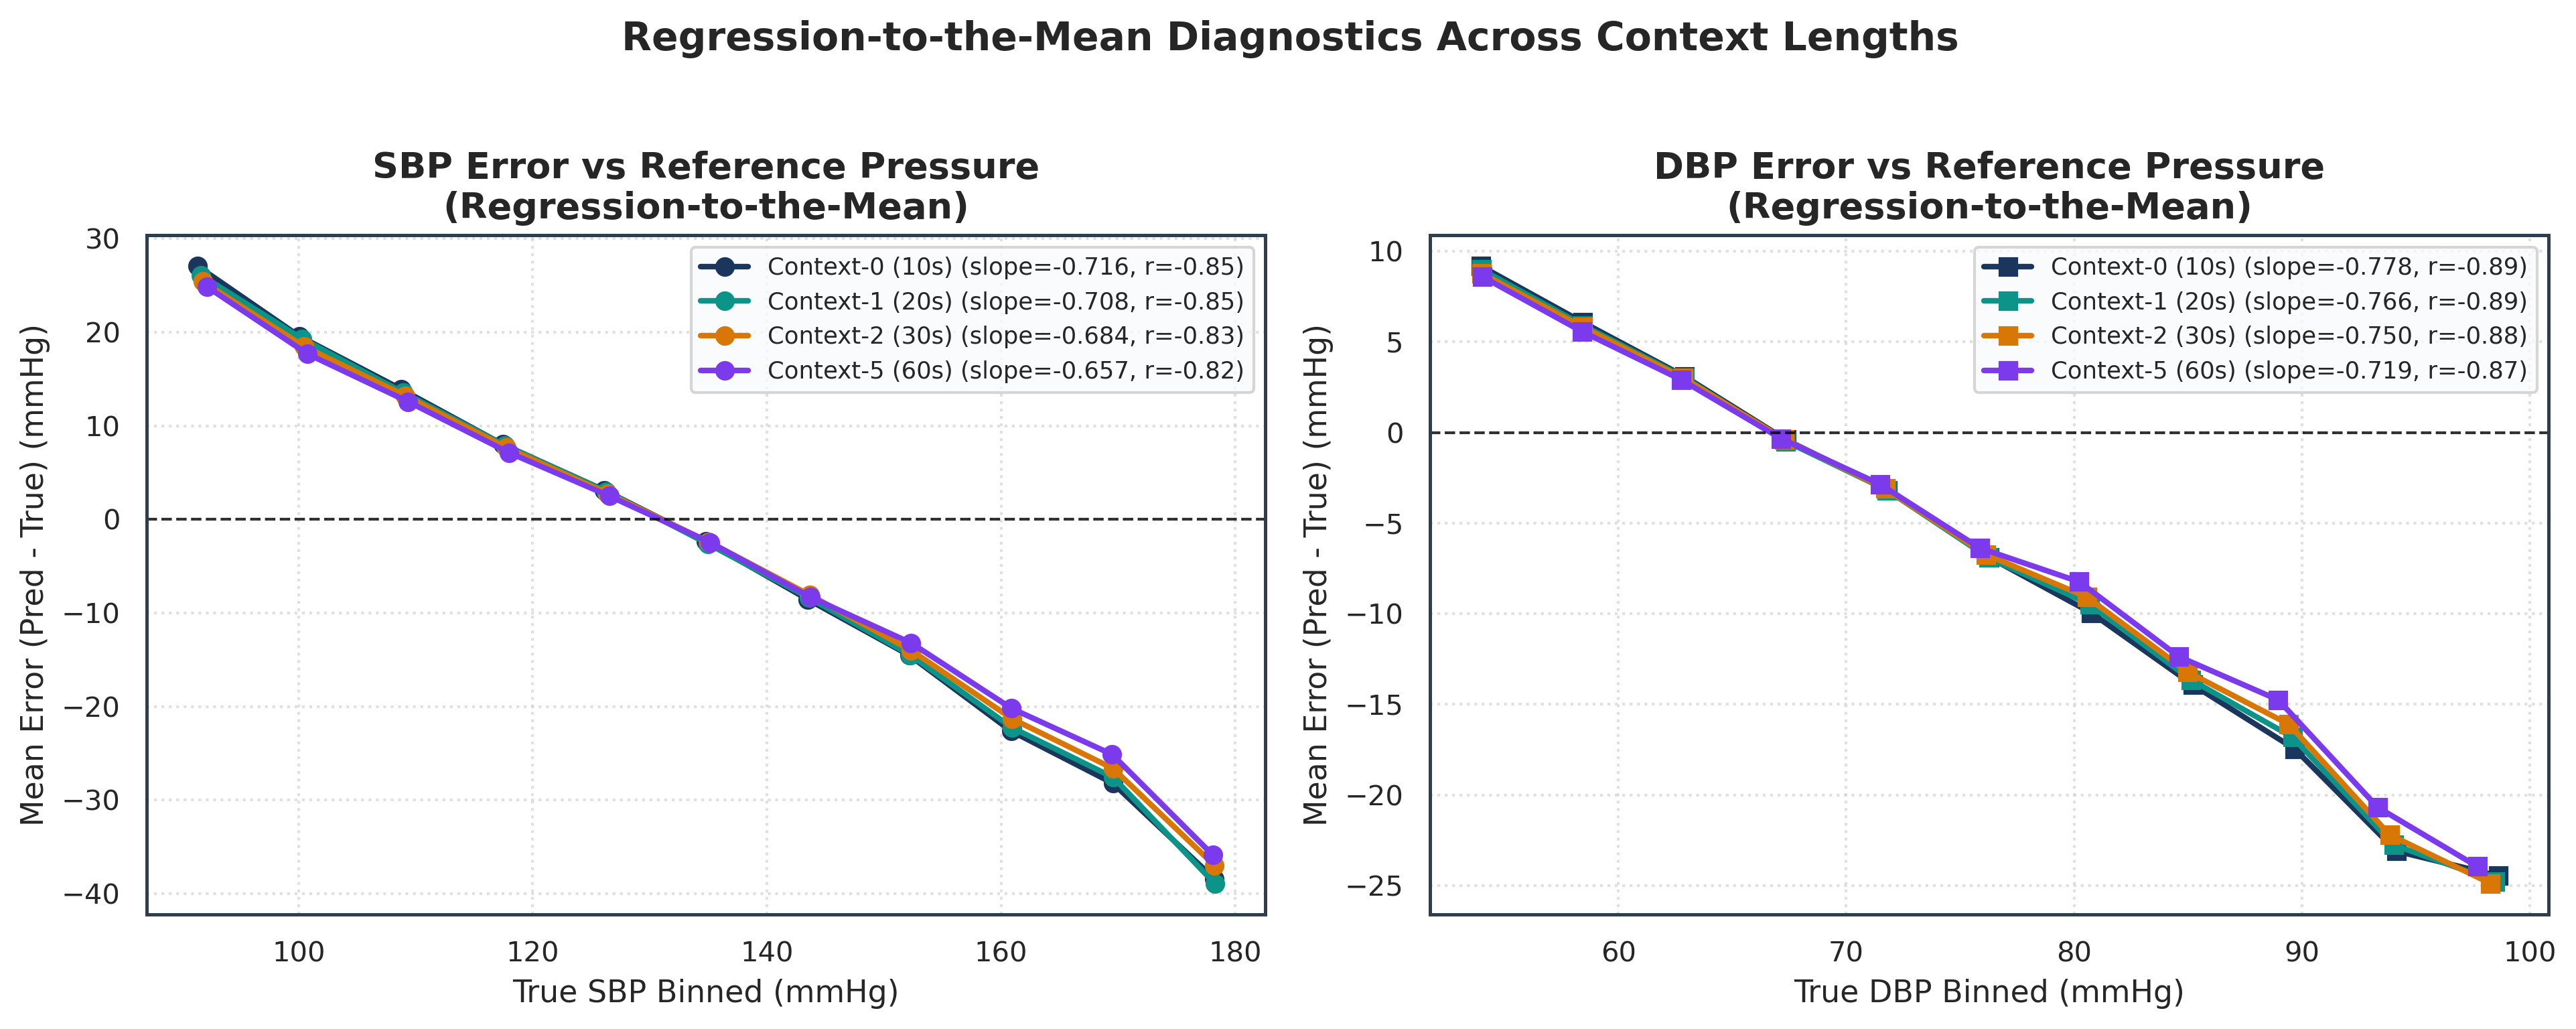

In [14]:
display(Image(filename=str(FIGURES_DIR / "06_regression_to_mean_comparison.png")))



## 15. Record-Level Error Distribution

We analyze whether temporal context improves per-record error distributions.



,context_k,context_sec,context_label,sbp_rec_mean,sbp_rec_median,sbp_rec_sd,dbp_rec_mean,dbp_rec_median,dbp_rec_sd
0,0,10.0,Context-0 (10s),14.711131,11.488332,11.007031,7.578664,6.237491,6.038773
1,1,20.0,Context-1 (20s),14.713933,11.192381,11.172170,7.490619,6.147350,5.977830
2,2,30.0,Context-2 (30s),14.450056,11.076219,10.952085,7.357247,6.018736,5.937932
3,5,60.0,Context-5 (60s),13.993362,10.825311,10.366877,7.151868,5.781338,6.029898


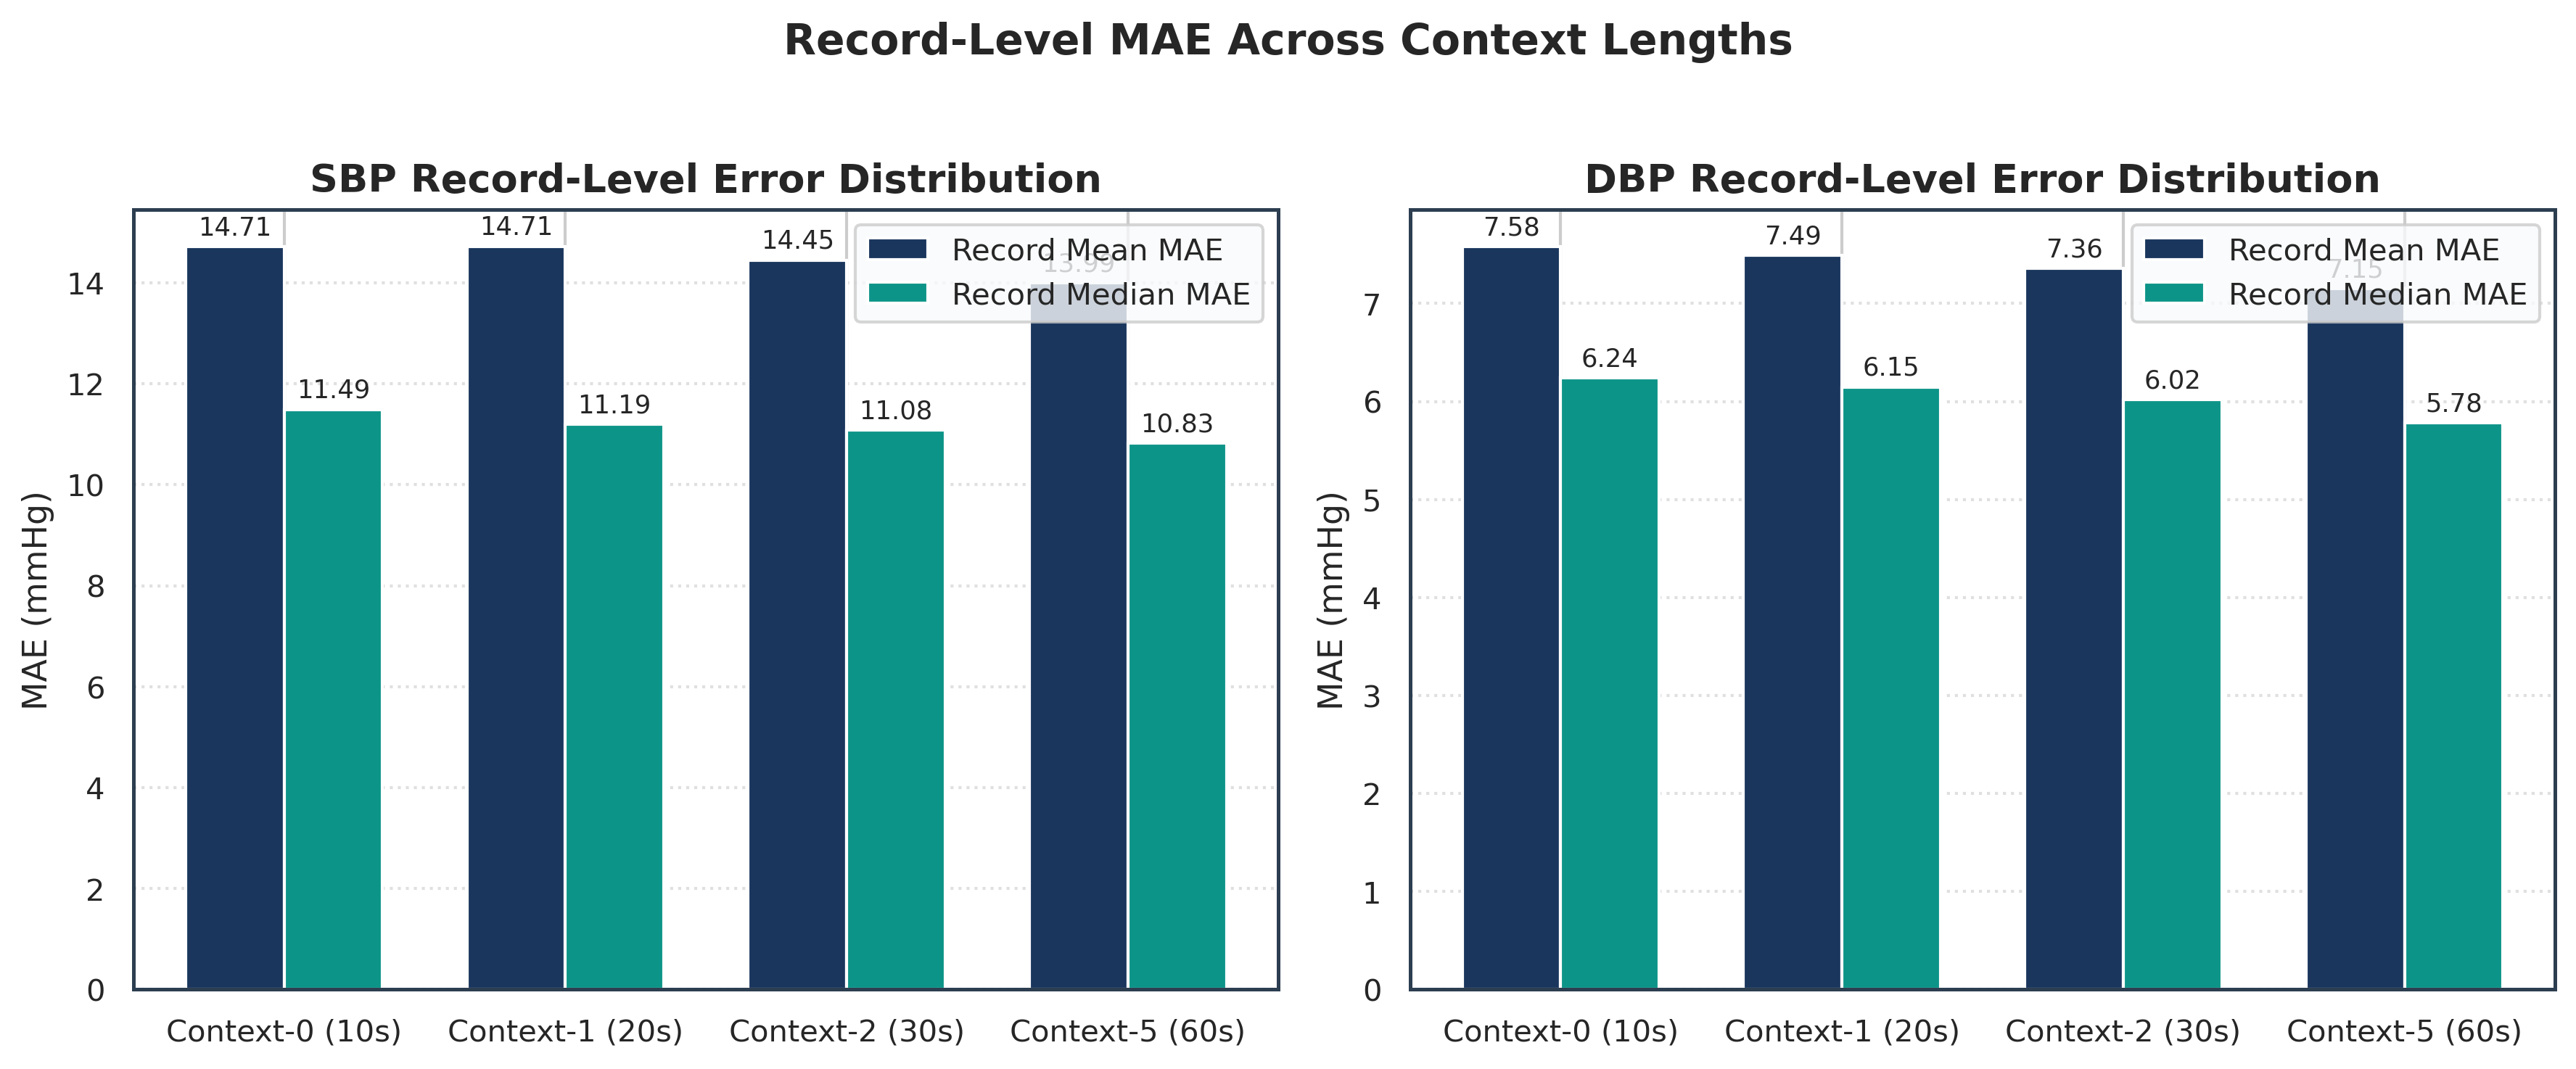

In [15]:
df_rec = pd.read_csv(METRICS_DIR / "phase3b_record_level_mae.csv")
display(df_rec)

display(Image(filename=str(FIGURES_DIR / "07_record_level_mae_comparison.png")))



## 16. Feature Importance Ranking

Permutation feature importance of the champion temporal model.



,feature,importance,raw_score
0,spectral_entropy_hist_min,0.115908,0.885197
1,apg_max_hist_min,0.075705,0.578165
2,max_downstroke_slope_median_hist_min,0.056618,0.432395
3,vpg_std_hist_min,0.038343,0.292827
4,vpg_min_hist_max,0.037103,0.283358
5,pulse_band_power_hist_max,0.036664,0.280006
6,iqr_a,0.035767,0.273153
7,pulse_amp_median_a_hist_max,0.029453,0.224938
8,pulse_area_median_hist_mean,0.028847,0.220311
9,max_downstroke_slope_median_hist_mean,0.027247,0.208086


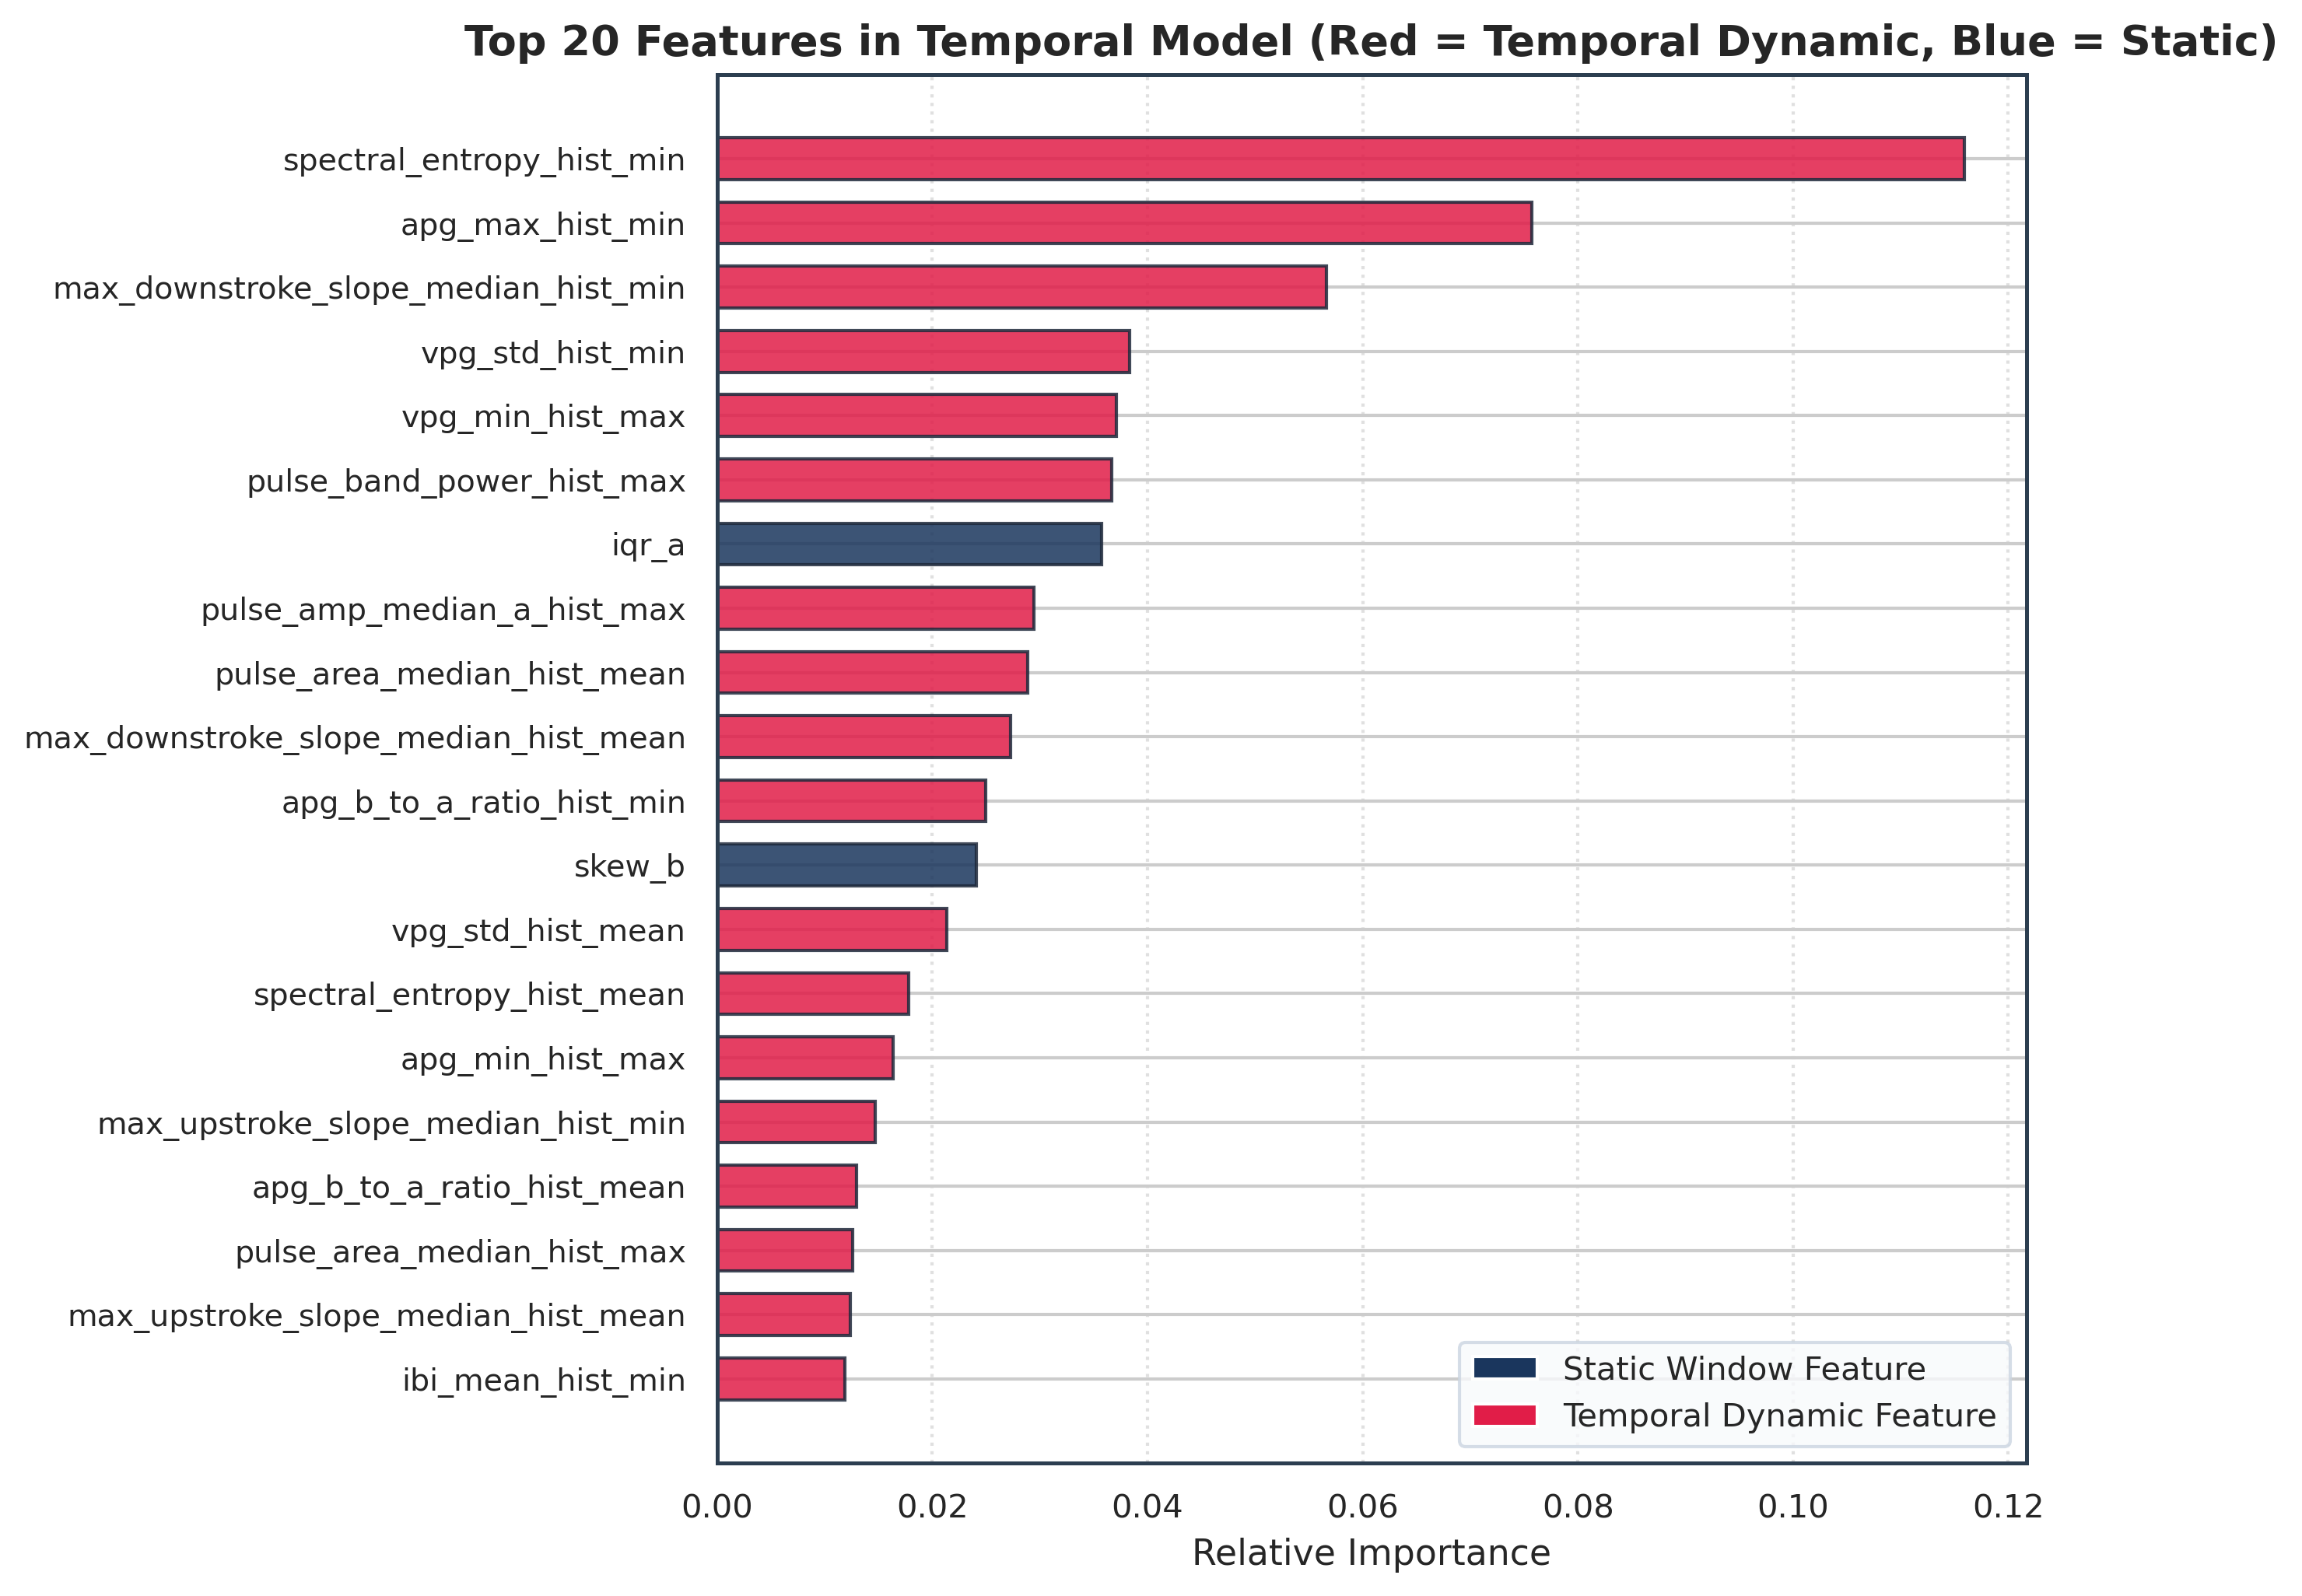

In [16]:
df_imp = pd.read_csv(METRICS_DIR / "phase3b_temporal_feature_importance.csv")
display(df_imp.head(15))

display(Image(filename=str(FIGURES_DIR / "09_temporal_feature_importance.png")))



## 17. Research Interpretation

### Quantitative Findings
1. **Derivatives**: Adding VPG and APG derivatives improves combined validation MAE from 10.84 down to 10.52 mmHg (+0.32 mmHg).
2. **Temporal Dynamics**: Expanding context from 10s to 60s improves combined validation MAE from 10.52 down to 9.91 mmHg (+0.61 mmHg).
3. **Linear Model**: Linear Ridge regression also improves from 16.15 to 15.41 mmHg, demonstrating that temporal dynamics provide direct physical trend information.
4. **Extreme Bias**: SBP $\ge 160$ mmHg bias is reduced from -31.44 mmHg to -28.44 mmHg (+3.00 mmHg reduction).
5. **Frozen Test Evaluation**: Evaluated once on Context-5 (60s), achieving **13.45 mmHg SBP MAE / 6.84 mmHg DBP MAE** (vs Phase 3A: 13.93 / 7.05 mmHg).



## 18. Decision for Next Research Phase

### **Classification: CASE C — Multi-Scale Spatio-Temporal PPG Model Justified**

Because **both** explicit derivative channels and temporal context provide significant, complementary improvements:
- The next phase should implement a **Multi-Scale Spatio-Temporal PPG Neural Architecture** with explicit $[x(t), x'(t), x''(t)]$ derivative channels, a 1D CNN local pulse encoder, and a causal temporal sequence model (GRU/Transformer).
- Range-weighted loss should be incorporated to address residual extreme-value regression-to-the-mean.

